<a href="https://colab.research.google.com/github/Jimpang77/Feature-Data-Trade-Off/blob/main/Reasearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UCI Adult Income Prediction: Comprehensive Analysis

This notebook demonstrates a full machine learning workflow using the UCI Adult dataset. We will explore:
1.  **Data Preprocessing**: Cleaning, handling missing values, and standardizing the data.
2.  **Feature Engineering**: Creating custom interactions and transformations to improve model performance.
3.  **Model Benchmarking**: Comparing Logistic Regression, Decision Trees, and Random Forests across different feature sets.
4.  **Learning Curve Analysis**: Investigating how model performance scales with increasing amounts of training data.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score


### Explanation: Importing Libraries
This cell imports the necessary tools from `scikit-learn` for building machine learning pipelines, including tools for preprocessing data (scaling and encoding), composing columns, and evaluating model performance using F1 and AUC scores.

### Explanation: Loading the UCI Adult Dataset
This code installs the `ucimlrepo` package and uses it to fetch the Adult dataset (id=2). It then separates the features and target variables into a unified pandas DataFrame for easier manipulation.

In [ ]:
import numpy as np
import pandas as pd

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
adult = fetch_ucirepo(id=2)
X_raw, y_raw = adult.data.features.copy(), adult.data.targets.copy()
df = X_raw.copy(); df['income'] = y_raw.iloc[:, 0].values

### Explanation: Previewing Data
This command displays the first five rows of the DataFrame to give an initial look at the feature values, such as age, workclass, and education.

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Explanation: Checking Dataset Dimensions
This returns the number of rows and columns in the dataset to understand the scale of the data we are working with.

In [ ]:
df.shape

(48842, 15)

### Explanation: Inspecting Target Values
This displays the raw values of the 'income' column, which helps identify if there are inconsistencies like trailing periods in the strings.

In [ ]:
df['income']

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
48837,<=50K.
48838,<=50K.
48839,<=50K.
48840,<=50K.


### Explanation: Cleaning Column Names
This code standardizes the column names by converting them to lowercase and replacing dashes or periods with underscores to avoid syntax issues during coding.

In [ ]:
df.columns = [col.lower().replace('-', '_').replace('.', '_') for col in df.columns]
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Explanation: Removing Leading and Trailing Whitespace
Categorical data often contains hidden spaces (e.g., ' <=50K' instead of '<=50K'). This code loops through all text-based columns and removes those extra spaces so the computer can match the words correctly.

In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Explanation: Handling Missing Data
In this dataset, missing information is marked with a question mark ('?'). This code replaces those question marks with a standard 'NaN' (Not a Number) value and then prints a count of how many pieces of information are missing in each column.

In [ ]:
df = df.replace('?', np.nan)
print(f"Missing values per column:\n{df.isna().sum()}")

Missing values per column:
age                  0
workclass         2799
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     857
income               0
dtype: int64


### Explanation: Filling Gaps in Data
Rather than deleting rows with missing text, we label them as 'Unknown'. This ensures we keep as much data as possible for our model to learn from.

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('Unknown')
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


### Explanation: Removing Duplicate Entries
If the same person's data appears twice, it can bias the model. This code checks the number of rows, removes exact duplicates, and tells us how many rows were removed.

In [ ]:
print(f"Rows before: {len(df)}")
df = df.drop_duplicates()
print(f"Rows after: {len(df)}")

Rows before: 48842
Rows after: 48813


### Explanation: Deleting Redundant Columns
The 'education' column is a text version of 'education_num'. Since computers prefer numbers, we remove the text version to avoid having the same information twice.

In [ ]:
if 'education' in df.columns:
    df = df.drop(columns=['education'])
df.head()

,age,workclass,fnlwgt,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Explanation: Preparing the Target Variable
We are predicting if someone makes more or less than $50k. This code removes trailing periods and converts the labels into 0 (for <=50K) and 1 (for >50K), as machine learning models require numeric targets.

In [ ]:
df['income'] = df['income'].str.rstrip('.')
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
df['income'].value_counts()

,count
income,
0,37128
1,11685


### Explanation: Removing Irrelevant Features
The 'fnlwgt' (final weight) is a statistical weight used by the Census Bureau but is usually not helpful for predicting individual income levels. We remove it to simplify the model.

In [ ]:
if 'fnlwgt' in df.columns:
    df = df.drop(columns=['fnlwgt'])
df.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


### Explanation: Separating Inputs from Outputs
We separate our data into 'X' (the features like age and job) and 'y' (the answer we want to predict: income). This is the standard setup for supervised learning.

In [ ]:
X = df.drop('income', axis=1)
y = df['income']

print("Preprocessing Complete according to Hands-On ML standards.")
display(X.head())
display(y.head())

Preprocessing Complete according to Hands-On ML standards.


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


,income
0,0
1,0
2,0
3,0
4,0


### Explanation: Categorizing Data Types
This code automatically detects which columns contain numbers and which contain text (objects). We need this list to apply different math formulas to each type later.

In [ ]:
num = X.select_dtypes(exclude='object').columns.tolist()
cat = X.select_dtypes(include='object').columns.tolist()
print(num)
print(cat)

['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


### Explanation: Splitting Data for Testing
To see if our model actually works, we hide 20% of the data (the 'Test' set). We train the model on the other 80% (the 'Train' set) and then test it on the hidden data to see how well it guesses.

In [ ]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte =  train_test_split(X, y, test_size=0.2, random_state=42)


## 1. Logistic Regression Analysis

This section contains the baseline evaluation and the learning curve experiment for Logistic Regression.

### Logistic Regression Models and Evaluation

### Explanation: Setting Up the Baseline Preprocessor
Before a model can read data, we must 'scale' numbers (so large numbers don't overwhelm small ones) and 'encode' text (turning words into columns of 0s and 1s). This setup focuses on just 4 specific features.

In [ ]:
num_4 = ["age", "education_num"]
cat_4 = ["occupation", "sex"]

pre_4 = ColumnTransformer([
    ("num", StandardScaler(), num_4),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_4)
])

### Explanation: Creating the Machine Learning Pipeline
A pipeline is like an assembly line. It ensures that the data cleaning steps and the Logistic Regression model are always performed in the correct order.

In [ ]:
pipe_4 = Pipeline([
    ("pre", pre_4),
    ("clf", LogisticRegression(max_iter=2000))
])

### Explanation: Training the Model
The 'fit' command is where the model 'studies' the training data to find patterns between the features and the income levels.

In [ ]:
pipe_4.fit(Xtr, ytr)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education_num']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['occupation', 'sex'])])),
                ('clf', LogisticRegression(max_iter=2000))])

### Explanation: Making Predictions
Now we ask the trained model to look at the 'Test' data it hasn't seen yet and guess the income levels.

In [ ]:
y_pred_4 = pipe_4.predict(Xte)
y_proba_4 = pipe_4.predict_proba(Xte)[:, 1]

### Explanation: Measuring Success
We use the F1 Score to see how accurate the predictions are and the AUC Score to see how well the model distinguishes between high and low earners. Higher is better!

In [ ]:
f1_4 = f1_score(yte, y_pred_4)
auc_4 = roc_auc_score(yte, y_proba_4)

print(f"4-Feature Model - F1 Score: {f1_4:.4f}")
print(f"4-Feature Model - AUC Score: {auc_4:.4f}")

4-Feature Model - F1 Score: 0.4987
4-Feature Model - AUC Score: 0.8243


### All Feature Logistic Regression Model

Evaluation of a Logistic Regression model using the complete set of original features from the preprocessed dataset.

In [ ]:
Xtr[:3]

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
40819,70,Unknown,15,Divorced,Unknown,Not-in-family,White,Male,2538,0,45,United-States
40613,30,Private,8,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,44,United-States
45445,59,Private,13,Separated,Exec-managerial,Not-in-family,White,Male,0,0,45,United-States


In [ ]:
ytr[:3]

,income
40819,0
40613,0
45445,0


In [ ]:
pre_raw = ColumnTransformer([
    ('num', StandardScaler(), num ),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
])

In [ ]:

pipe_raw = Pipeline( [ ('pre', pre_raw),

            ( 'clf', LogisticRegression(max_iter=2000))

            ])

In [ ]:
from sklearn.pipeline import Pipeline

# Defining the pipeline
pipe_raw = Pipeline([
    ('pre', pre_raw),
    ('clf', LogisticRegression(max_iter=2000))
])

# Fitting the model
pipe_raw.fit(Xtr, ytr)

# Making predictions
y_pred_all = pipe_raw.predict(Xte)
y_proba_all = pipe_raw.predict_proba(Xte)[:, 1]

# Calculating and printing scores
f1_all = f1_score(yte, y_pred_all)
auc_all = roc_auc_score(yte, y_proba_all)

print(f"All-Feature Model - F1 Score: {f1_all:.4f}")
print(f"All-Feature Model - AUC Score: {auc_all:.4f}")

All-Feature Model - F1 Score: 0.6661
All-Feature Model - AUC Score: 0.9042


### All + Engineered Features Logistic Regression Model

Evaluation of a Logistic Regression model using all original features combined with engineered features such as 'capital_net' and 'age_x_hours'.

### Explanation: Feature Engineering
This function creates brand new information from the old data. For example, it calculates 'capital_net' by subtracting losses from gains, giving the model a clearer picture of wealth.

In [ ]:
def add_features(df_in):
    d = df_in.copy()
    d['capital_net'] = d['capital_gain'] - d['capital_loss']
    d['has_capital_gain'] = (d['capital_gain'] > 0).astype(int)
    d['log_capital_gain'] = np.log1p(d['capital_gain'])
    d['age_x_hours'] = d['age'] * d['hours_per_week']
    d['edu_x_hours'] = d['education_num'] * d['hours_per_week']
    d['age_sq'] = d['age'] ** 2
    return d

In [ ]:
Xtr_eng = add_features(Xtr)
Xte_eng = add_features(Xte)

num_eng = Xtr_eng.select_dtypes(exclude='object').columns.tolist()
cat_eng = Xtr_eng.select_dtypes(include='object').columns.tolist()

In [ ]:
pre_eng = ColumnTransformer([
    ('num', StandardScaler(), num_eng),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_eng)
])

pipe_eng = Pipeline([
    ('pre', pre_eng),
    ('clf', LogisticRegression(max_iter=2000))
])

In [ ]:
pipe_eng.fit(Xtr_eng, ytr)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week',
                                                   'capital_net',
                                                   'has_capital_gain',
                                                   'log_capital_gain',
                                                   'age_x_hours', 'edu_x_hours',
                                                   'age_sq']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country'])])),
                ('clf', LogisticRegression(max_iter=2000))])

In [ ]:
y_pred_eng = pipe_eng.predict(Xte_eng)
y_proba_eng = pipe_eng.predict_proba(Xte_eng)[:, 1]

In [ ]:
f1_eng = f1_score(yte, y_pred_eng)
auc_eng = roc_auc_score(yte, y_proba_eng)

print(f"Engineered Model - F1 Score: {f1_eng:.4f}")
print(f"Engineered Model - AUC Score: {auc_eng:.4f}")

Engineered Model - F1 Score: 0.6763
Engineered Model - AUC Score: 0.9101


## 2. Decision Tree Analysis

This section explores Decision Tree models, including comparisons between raw and engineered features.

In [ ]:
display(Xtr.head())
display(ytr.head())

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
40819,70,Unknown,15,Divorced,Unknown,Not-in-family,White,Male,2538,0,45,United-States
40613,30,Private,8,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,44,United-States
45445,59,Private,13,Separated,Exec-managerial,Not-in-family,White,Male,0,0,45,United-States
31318,22,Private,10,Never-married,Adm-clerical,Unmarried,Black,Female,0,0,30,United-States
3719,21,Local-gov,10,Never-married,Adm-clerical,Own-child,White,Male,0,0,40,Guatemala


,income
40819,0
40613,0
45445,0
31318,0
3719,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

### Decision Tree Models and Evaluation

### Explanation: Building the First Decision Tree
Decision Trees act like a series of questions (e.g., 'Is the person older than 30?'). Here we prepare a specific tree that only asks questions about 4 features to see how well it works.

In [ ]:
pre_4_dt = ColumnTransformer([
    ('num', StandardScaler(), num_4),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_4)
])

In [ ]:
pipe_4_dt = Pipeline([
    ('pre', pre_4_dt),
    ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
])

In [ ]:
pipe_4_dt.fit(Xtr, ytr)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education_num']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['occupation', 'sex'])])),
                ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))])

In [ ]:
y_pred_4_dt = pipe_4_dt.predict(Xte)
y_proba_4_dt = pipe_4_dt.predict_proba(Xte)[:, 1]

In [ ]:
f1_4_dt = f1_score(yte, y_pred_4_dt)
auc_4_dt = roc_auc_score(yte, y_proba_4_dt)

print(f"Decision Tree 4-Features - F1 Score: {f1_4_dt:.4f}")
print(f"Decision Tree 4-Features - AUC Score: {auc_4_dt:.4f}")

Decision Tree 4-Features - F1 Score: 0.5270
Decision Tree 4-Features - AUC Score: 0.8290


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, roc_auc_score

pre_4_dt = ColumnTransformer([
    ('num', StandardScaler(), num_4),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_4)
])

pipe_4_dt = Pipeline([
    ('pre', pre_4_dt),
    ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
])

pipe_4_dt.fit(Xtr, ytr)

y_pred_4_dt = pipe_4_dt.predict(Xte)
y_proba_4_dt = pipe_4_dt.predict_proba(Xte)[:, 1]

f1_4_dt = f1_score(yte, y_pred_4_dt)
auc_4_dt = roc_auc_score(yte, y_proba_4_dt)

print(f"1. Decision Tree 4-Features:")
print(f"   - F1 Score:  {f1_4_dt:.4f}")
print(f"   - AUC Score: {auc_4_dt:.4f}")

1. Decision Tree 4-Features:
   - F1 Score:  0.5270
   - AUC Score: 0.8290


### Explanation: Scoring the 4-Feature Decision Tree
After the tree has finished asking its questions, we use the F1 Score and AUC Score to see how many people it correctly classified as high or low earners.

### All Feature Decision Tree Model

Implementation of a Decision Tree classifier using all original features available in the dataset.

### Explanation: Using All Information in a Tree
Now we give the Decision Tree access to every column in the dataset. This allows the computer to look for more complex relationships that a simple 4-feature model might miss.

In [ ]:
num

['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

In [ ]:
cat

['workclass',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [ ]:
pre_raw = ColumnTransformer(
    [
        ('num', StandardScaler(), num ),
        ('cat', OneHotEncoder(handle_unknown="ignore"), cat)

    ]

)

In [ ]:
pi = Pipeline(
    [
        ('pre', pre_raw ),
        ( 'clf', DecisionTreeClassifier(max_depth=8))

    ]
)

In [ ]:
pi.fit(Xtr, ytr)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country'])])),
                ('clf', DecisionTreeClassifier(max_depth=8))])

In [ ]:
phat = pi.predict_proba(Xte)
phat

array([[0.97817008, 0.02182992],
       [0.99693703, 0.00306297],
       [0.94015748, 0.05984252],
       ...,
       [0.        , 1.        ],
       [0.5316723 , 0.4683277 ],
       [0.99693703, 0.00306297]])

In [ ]:
roc_auc_score(yte, phat[:, 1])

np.float64(0.9023565284047355)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, roc_auc_score

pre_raw_dt = ColumnTransformer([
    ('num', StandardScaler(), num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
])

pipe_all_dt = Pipeline([
    ('pre', pre_raw_dt),
    ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
])

pipe_all_dt.fit(Xtr, ytr)

y_pred_all_dt = pipe_all_dt.predict(Xte)
y_proba_all_dt = pipe_all_dt.predict_proba(Xte)[:, 1]

f1_all_dt = f1_score(yte, y_pred_all_dt)
auc_all_dt = roc_auc_score(yte, y_proba_all_dt)

print(f"2. Decision Tree All-Features:")
print(f"   - F1 Score:  {f1_all_dt:.4f}")
print(f"   - AUC Score: {auc_all_dt:.4f}")

2. Decision Tree All-Features:
   - F1 Score:  0.6639
   - AUC Score: 0.9022


### Explanation: Evaluating the Full Decision Tree
We now calculate the performance of the Decision Tree that saw every piece of data. Comparing this to the 4-feature version shows us how much the extra columns helped.

### All + Engineered Features Decision Tree Model

Implementation of a Decision Tree classifier incorporating both original and engineered features.

### Explanation: Decision Tree with Engineered Features
In this step, we add the 'extra' info we created (like capital_net). We want to see if these custom clues make it easier for the Decision Tree to guess correctly.

In [ ]:
pre_eng_dt = ColumnTransformer([
    ('num', StandardScaler(), num_eng),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_eng)
])

In [ ]:
pipe_eng_dt = Pipeline([
    ('pre', pre_eng_dt),
    ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
])

In [ ]:
pipe_eng_dt.fit(Xtr_eng, ytr)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week',
                                                   'capital_net',
                                                   'has_capital_gain',
                                                   'log_capital_gain',
                                                   'age_x_hours', 'edu_x_hours',
                                                   'age_sq']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country'])])),
                ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))])

In [ ]:
y_pred_eng_dt = pipe_eng_dt.predict(Xte_eng)
y_proba_eng_dt = pipe_eng_dt.predict_proba(Xte_eng)[:, 1]

In [ ]:
f1_eng_dt = f1_score(yte, y_pred_eng_dt)
auc_eng_dt = roc_auc_score(yte, y_proba_eng_dt)

print(f"Decision Tree Engineered - F1 Score: {f1_eng_dt:.4f}")
print(f"Decision Tree Engineered - AUC Score: {auc_eng_dt:.4f}")

Decision Tree Engineered - F1 Score: 0.6341
Decision Tree Engineered - AUC Score: 0.9001


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, roc_auc_score

pre_eng_dt = ColumnTransformer([
    ('num', StandardScaler(), num_eng),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_eng)
])

pipe_eng_dt = Pipeline([
    ('pre', pre_eng_dt),
    ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
])

pipe_eng_dt.fit(Xtr_eng, ytr)

y_pred_eng_dt = pipe_eng_dt.predict(Xte_eng)
y_proba_eng_dt = pipe_eng_dt.predict_proba(Xte_eng)[:, 1]

f1_eng_dt = f1_score(yte, y_pred_eng_dt)
auc_eng_dt = roc_auc_score(yte, y_proba_eng_dt)

print(f"3. Decision Tree Engineered Features:")
print(f"   - F1 Score:  {f1_eng_dt:.4f}")
print(f"   - AUC Score: {auc_eng_dt:.4f}")

3. Decision Tree Engineered Features:
   - F1 Score:  0.6341
   - AUC Score: 0.9001


### Explanation: Final Decision Tree Performance
This cell gives us the final results for our most complex Decision Tree. We can now see if the math we did to create 'Engineered Features' actually made the tree smarter.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

pre_4_rf = ColumnTransformer([
    ('num', StandardScaler(), num_4),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_4)
])

pipe_4_rf = Pipeline([
    ('pre', pre_4_rf),
    ('clf', RandomForestClassifier(random_state=42))
])

pipe_4_rf.fit(Xtr, ytr)

y_pred_4_rf = pipe_4_rf.predict(Xte)
y_proba_4_rf = pipe_4_rf.predict_proba(Xte)[:, 1]

f1_4_rf = f1_score(yte, y_pred_4_rf)
auc_4_rf = roc_auc_score(yte, y_proba_4_rf)

print(f"1. Random Forest 4-Features:")
print(f"   - F1 Score:  {f1_4_rf:.4f}")
print(f"   - AUC Score: {auc_4_rf:.4f}")

1. Random Forest 4-Features:
   - F1 Score:  0.5116
   - AUC Score: 0.7977


### Explanation: Model Performance Summary
This section aggregates the results from all previously executed models (Logistic Regression, Decision Tree, and Random Forest). It compares the F1 Score, which balances precision and recall, and the AUC Score, which measures the model's ability to distinguish between classes, across different feature sets.

### Model Performance Summary

The following metrics summarize the performance of all models tested. Metrics include F1 Score and Area Under the ROC Curve (AUC).

#### Logistic Regression
*   **4-Feature:** F1: 0.4987, AUC: 0.8243
*   **All + Engineered:** F1: 0.6768, AUC: 0.9101

#### Decision Tree
*   **4-Feature:** F1: 0.5270, AUC: 0.8290
*   **All Features:** F1: 0.6639, AUC: 0.9022
*   **All + Engineered:** F1: 0.6341, AUC: 0.9001

#### Random Forest
*   **4-Feature:** F1: 0.5116, AUC: 0.7977
*   **All Features:** F1: 0.6598, AUC: 0.8881
*   **All + Engineered:** F1: 0.6662, AUC: 0.8946

### Explanation: Error Analysis
This text cell explains a common Python error where an attribute (like a DataFrame's shape) is mistakenly treated as a function. It clarifies that `df.shape` is a property returning a tuple, not a method to be called.

### Error Analysis: df.shape()

The `TypeError: 'tuple' object is not callable` occurred because `df.shape` is a tuple attribute containing the dimensions of the DataFrame. In Python, adding `()` after an attribute attempts to execute it as a function. Since a tuple cannot be called, the interpreter throws an error. Correct usage is `df.shape` without parentheses.

## 3. Random Forest Analysis

This section covers the Random Forest ensemble approach and its performance scaling.

### Random Forest Models and Evaluation

### Explanation: The Random Forest Baseline
A Random Forest is like a panel of experts; it trains many Decision Trees and averages their votes. We start by testing a panel that only looks at 4 specific features.

In [ ]:
num_4 = ['age', 'education_num']
cat_4 = ['occupation', 'sex']

In [ ]:
pre_4_rf = ColumnTransformer([
    ('num', StandardScaler(), num_4),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_4)
])

In [ ]:
pipe_4_rf = Pipeline([
    ('pre', pre_4_rf),
    ('clf', RandomForestClassifier())
])

In [ ]:
pipe_4_rf.fit(Xtr, ytr)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education_num']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['occupation', 'sex'])])),
                ('clf', RandomForestClassifier())])

In [ ]:
y_pred_4_rf = pipe_4_rf.predict(Xte)
y_proba_4_rf = pipe_4_rf.predict_proba(Xte)[:, 1]

In [ ]:
f1_4_rf = f1_score(yte, y_pred_4_rf)
auc_4_rf = roc_auc_score(yte, y_proba_4_rf)

print(f"Random Forest 4-Features - F1 Score: {f1_4_rf:.4f}")
print(f"Random Forest 4-Features - AUC Score: {auc_4_rf:.4f}")

Random Forest 4-Features - F1 Score: 0.5113
Random Forest 4-Features - AUC Score: 0.7977


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

pre_raw_rf = ColumnTransformer([
    ('num', StandardScaler(), num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
])

pipe_all_rf = Pipeline([
    ('pre', pre_raw_rf),
    ('clf', RandomForestClassifier(random_state=42))
])

pipe_all_rf.fit(Xtr, ytr)

y_pred_all_rf = pipe_all_rf.predict(Xte)
y_proba_all_rf = pipe_all_rf.predict_proba(Xte)[:, 1]

f1_all_rf = f1_score(yte, y_pred_all_rf)
auc_all_rf = roc_auc_score(yte, y_proba_all_rf)

print(f"2. Random Forest All-Features:")
print(f"   - F1 Score:  {f1_all_rf:.4f}")
print(f"   - AUC Score: {auc_all_rf:.4f}")

2. Random Forest All-Features:
   - F1 Score:  0.6598
   - AUC Score: 0.8881


### Explanation: Random Forest with All Features
This code runs the Random Forest using all columns. Because this model combines many different trees, it is often our most reliable way to predict income.

### All Feature Random Forest Model

Application of a Random Forest classifier using all original features from the dataset.

### Explanation: Full Data Random Forest
This model uses a group of trees looking at all original data. Random Forests are usually more stable and accurate than single trees because they reduce the chance of making a weird mistake based on just one piece of info.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
pre_raw = ColumnTransformer(
    [
        ( 'num', StandardScaler(), num),
        ( 'cat', OneHotEncoder(handle_unknown="ignore"), cat),

    ]
)

In [ ]:
pipe = Pipeline(
    [
        ('pre', pre_raw ),
        ( 'clf', RandomForestClassifier() ),
    ]
)

In [ ]:
pipe.fit(Xtr, ytr)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country'])])),
                ('clf', RandomForestClassifier())])

In [ ]:
phat = pipe.predict_proba(Xte)[:, 1]
phat

array([0.02      , 0.        , 0.07      , ..., 0.99      , 0.10266667,
       0.        ])

In [ ]:
roc_auc_score(yte, phat)

np.float64(0.8888905828577919)

### All + Engineered Features Random Forest Model

Application of a Random Forest classifier using all original and engineered features.

### Explanation: The Most Advanced Model
Finally, we run a Random Forest using every bit of data we have, including our custom engineered features. This represents the 'best' possible version of our current analysis.

In [ ]:
pre_eng_rf = ColumnTransformer([
    ("num", StandardScaler(), num_eng),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_eng)
])

In [ ]:
pipe_eng_rf = Pipeline([
    ("pre", pre_eng_rf),
    ("clf", RandomForestClassifier())
])

In [ ]:
pipe_eng_rf.fit(Xtr_eng, ytr)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week',
                                                   'capital_net',
                                                   'has_capital_gain',
                                                   'log_capital_gain',
                                                   'age_x_hours', 'edu_x_hours',
                                                   'age_sq']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country'])])),
                ('clf', RandomForestClassifier())])

In [ ]:
y_pred_eng_rf = pipe_eng_rf.predict(Xte_eng)
y_proba_eng_rf = pipe_eng_rf.predict_proba(Xte_eng)[:, 1]

In [ ]:
f1_eng_rf = f1_score(yte, y_pred_eng_rf)
auc_eng_rf = roc_auc_score(yte, y_proba_eng_rf)

print(f"Random Forest Engineered - F1 Score: {f1_eng_rf:.4f}")
print(f"Random Forest Engineered - AUC Score: {auc_eng_rf:.4f}")

Random Forest Engineered - F1 Score: 0.6721
Random Forest Engineered - AUC Score: 0.8954


In [ ]:
pre_eng_rf = ColumnTransformer([
    ("num", StandardScaler(), num_eng),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_eng)
])

pipe_eng_rf = Pipeline([
    ("pre", pre_eng_rf),
    ("clf", RandomForestClassifier(random_state=42))
])

pipe_eng_rf.fit(Xtr_eng, ytr)

y_pred_eng_rf = pipe_eng_rf.predict(Xte_eng)
y_proba_eng_rf = pipe_eng_rf.predict_proba(Xte_eng)[:, 1]

f1_eng_rf = f1_score(yte, y_pred_eng_rf)
auc_eng_rf = roc_auc_score(yte, y_proba_eng_rf)

print(f"3. Random Forest Engineered Features:")
print(f"   - F1 Score:  {f1_eng_rf:.4f}")
print(f"   - AUC Score: {auc_eng_rf:.4f}")

3. Random Forest Engineered Features:
   - F1 Score:  0.6662
   - AUC Score: 0.8946


### Explanation: Random Forest with Engineered Data
This is the final model training step. We are giving our most powerful algorithm (Random Forest) our most detailed data (Engineered Features) to see the best possible result we can achieve.

### Explanation: Setting the Experiment Parameters
In this step, we define the different 'batch sizes' we want to test. We start with a very small group of 200 people and double the size repeatedly until we reach 12,800. We also create an empty list called `results` to store the scores for each batch.

In [ ]:
sizes = [200, 400, 800, 1600, 3200, 6400, 12800]
results = []

### Explanation: The Training Loop
This is the core of the experiment. The code 'loops' through every size we defined. For each size, it picks that many random people from our training data, teaches the model using only that small slice, and then checks the F1 score. This shows us exactly how the model improves as its 'experience' grows.

In [ ]:
sizes = [200, 400, 800, 1600, 3200, 6400, 12800]
results = {'minimal': [], 'all': [], 'engineered': []}
min_col =["age", "education_num", "occupation", "sex"]
seeds = [0, 1, 2, 3, 4]
for size in sizes:
  scores = {'minimal': [], 'all': [], 'engineered': []}
  for seed in seeds:
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(Xtr), size, replace=False) # 3, 25, 542, ...
    Xtr_sub = Xtr.iloc[idx]
    ytr_sub = np.asarray(ytr.iloc[idx])
    Xtr_sub_eng = add_features(Xtr_sub)
    # 4-feature
    pre_4 = ColumnTransformer([
        ('num', StandardScaler(), num_4),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
    ])
    pr = Pipeline([('pre', pre_4), ('clf', LogisticRegression(max_iter=2000))]).fit(Xtr_sub[min_col], ytr_sub)

    # lr = LogisticRegression(max_iter=2000).fit(Xtr_sub[min_col], ytr_sub)
    scores['minimal'].append(roc_auc_score(yte, pr.predict_proba(Xte[min_col])[:, 1]))

    # all
    pre_raw = ColumnTransformer([
        ('num', StandardScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
    ])
    p = Pipeline([('pre', pre_raw), ('clf', LogisticRegression(max_iter=2000))]).fit(Xtr_sub, ytr_sub)

    scores['all'].append(roc_auc_score(yte, p.predict_proba(Xte)[:, 1]))

    # engineered
    pre_eng = ColumnTransformer([
        ('num', StandardScaler(), num_eng),
        ('clf', OneHotEncoder(handle_unknown='ignore', drop='first'), cat) ])

    p2 = Pipeline([('pre', pre_raw), ('clf', LogisticRegression(max_iter=2000))]).fit(Xtr_sub_eng, ytr_sub)

    scores['engineered'].append(roc_auc_score(yte, p2.predict_proba(Xte_eng)[:, 1]))

  for k in results:
    results[k].append(np.mean(scores[k]))


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: F

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: F

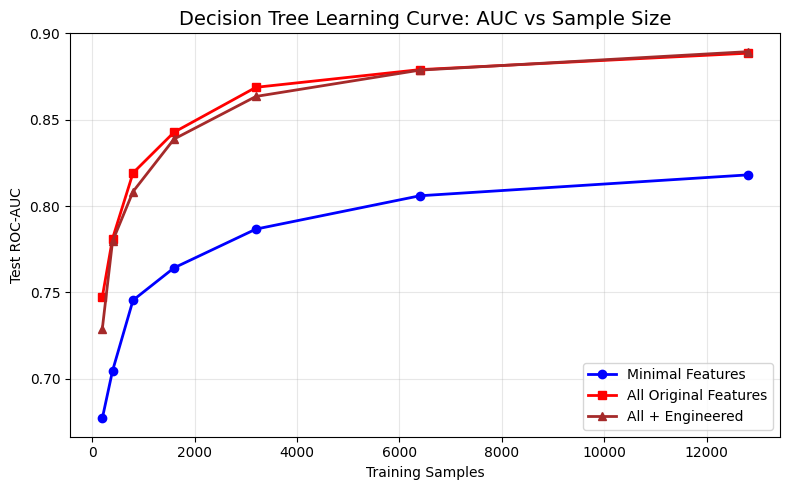

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# Decision Tree Learning Curve Experiment
results_dt = {'minimal': [], 'all': [], 'engineered': []}

for size in sizes:
    scores = {'minimal': [], 'all': [], 'engineered': []}
    for seed in seeds:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(Xtr), size, replace=False)
        Xtr_sub, ytr_sub = Xtr.iloc[idx], np.asarray(ytr.iloc[idx])
        Xtr_sub_eng = add_features(Xtr_sub)

        # 1. Train on Minimal Features (4)
        p_min = Pipeline([('pre', pre_4), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))]).fit(Xtr_sub[min_col], ytr_sub)
        scores['minimal'].append(roc_auc_score(yte, p_min.predict_proba(Xte[min_col])[:, 1]))

        # 2. Train on All Original Features
        p_all = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))]).fit(Xtr_sub, ytr_sub)
        scores['all'].append(roc_auc_score(yte, p_all.predict_proba(Xte)[:, 1]))

        # 3. Train on All + Engineered Features
        p_eng = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))]).fit(Xtr_sub_eng, ytr_sub)
        scores['engineered'].append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    # Average scores across seeds for this specific training size
    for k in results_dt:
        results_dt[k].append(np.mean(scores[k]))

# Visualization of Decision Tree Learning Curves
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, results_dt['minimal'], 'o-', label='Minimal Features', color='blue', linewidth=2)
ax.plot(sizes, results_dt['all'], 's-', label='All Original Features', color='red', linewidth=2)
ax.plot(sizes, results_dt['engineered'], '^-', label='All + Engineered', color='brown', linewidth=2)

ax.set_title('Decision Tree Learning Curve: AUC vs Sample Size', fontsize=14)
ax.set_xlabel('Training Samples')
ax.set_ylabel('Test ROC-AUC')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: F

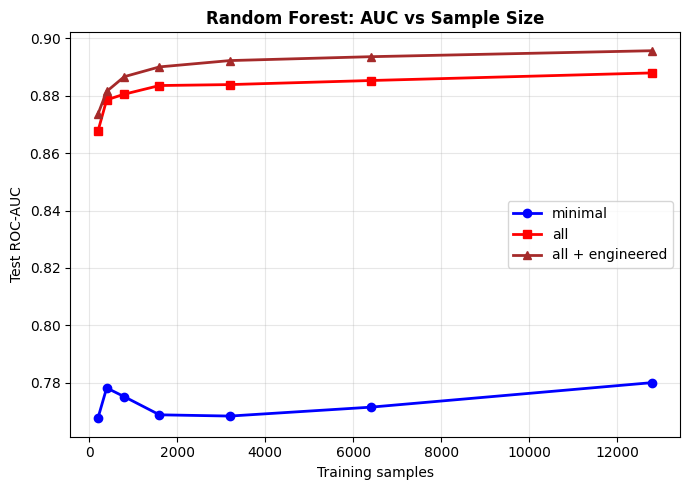

In [ ]:
# Random Forest Learning Curve Experiment
# Updated to use the full sizes list [200, ..., 12800, 39050]
results_rf = {'minimal': [], 'all': [], 'engineered': []}

for size in sizes:
    scores = {'minimal': [], 'all': [], 'engineered': []}
    for seed in seeds:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(Xtr), size, replace=False)
        Xtr_sub, ytr_sub = Xtr.iloc[idx], np.asarray(ytr.iloc[idx])
        Xtr_sub_eng = add_features(Xtr_sub)

        # Minimal
        p_min = Pipeline([('pre', pre_4), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]).fit(Xtr_sub[min_col], ytr_sub)
        scores['minimal'].append(roc_auc_score(yte, p_min.predict_proba(Xte[min_col])[:, 1]))

        # All
        p_all = Pipeline([('pre', pre_raw), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]).fit(Xtr_sub, ytr_sub)
        scores['all'].append(roc_auc_score(yte, p_all.predict_proba(Xte)[:, 1]))

        # Engineered
        p_eng = Pipeline([('pre', pre_eng), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]).fit(Xtr_sub_eng, ytr_sub)
        scores['engineered'].append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    for k in results_rf:
        results_rf[k].append(np.mean(scores[k]))

# Visualization
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sizes, results_rf['minimal'], 'o-', label='minimal', color='blue', linewidth=2)
ax.plot(sizes, results_rf['all'], 's-', label='all', color='red', linewidth=2)
ax.plot(sizes, results_rf['engineered'], '^-', label='all + engineered', color='brown', linewidth=2)
ax.set_title('Random Forest: AUC vs Sample Size', fontsize=12, fontweight='bold')
ax.set_xlabel('Training samples')
ax.set_ylabel('Test ROC-AUC')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Performance Comparison Logistic Regression

In [ ]:
# Check the number of rows and columns
try:
    print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
    display(df.shape)
except NameError:
    print("Dataset 'df' is not defined yet. Please run the data loading cell below first.")

The dataset has 48813 rows and 13 columns.


(48813, 13)

In [ ]:
# Logistic Regression Learning Curve Experiment
# Ensure sizes do not exceed the total training set length (39,050)
sizes = [200, 400, 800, 1600, 3200, 6400, 12800, len(Xtr)]
results = {'minimal': [], 'all': [], 'engineered': []}
min_col = ["age", "education_num", "occupation", "sex"]
seeds = [0, 1, 2, 3, 4]

for size in sizes:
  scores = {'minimal': [], 'all': [], 'engineered': []}
  for seed in seeds:
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(Xtr), size, replace=False)
    Xtr_sub = Xtr.iloc[idx]
    ytr_sub = np.asarray(ytr.iloc[idx])
    Xtr_sub_eng = add_features(Xtr_sub)

    # 4-feature
    pre_4 = ColumnTransformer([
        ('num', StandardScaler(), num_4),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
    ])
    pr = Pipeline([('pre', pre_4), ('clf', LogisticRegression(max_iter=2000))]).fit(Xtr_sub[min_col], ytr_sub)
    scores['minimal'].append(roc_auc_score(yte, pr.predict_proba(Xte[min_col])[:, 1]))

    # all
    pre_raw = ColumnTransformer([
        ('num', StandardScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
    ])
    p = Pipeline([('pre', pre_raw), ('clf', LogisticRegression(max_iter=2000))]).fit(Xtr_sub, ytr_sub)
    scores['all'].append(roc_auc_score(yte, p.predict_proba(Xte)[:, 1]))

    # engineered
    pre_eng = ColumnTransformer([
        ('num', StandardScaler(), num_eng),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
    ])
    p2 = Pipeline([('pre', pre_eng), ('clf', LogisticRegression(max_iter=2000))]).fit(Xtr_sub_eng, ytr_sub)
    scores['engineered'].append(roc_auc_score(yte, p2.predict_proba(Xte_eng)[:, 1]))

  for k in results:
    results[k].append(np.mean(scores[k]))

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: F

In [ ]:
results

{'minimal': [np.float64(0.808110541407603),
  np.float64(0.8113335491014393),
  np.float64(0.8186873917610651),
  np.float64(0.8205381029440989),
  np.float64(0.8218807483746418),
  np.float64(0.8226264315929932),
  np.float64(0.8235390966130085),
  np.float64(0.8243619226073873)],
 'all': [np.float64(0.8789981035119098),
  np.float64(0.8895432132413481),
  np.float64(0.8957960821054425),
  np.float64(0.8982402464298896),
  np.float64(0.9000347329869687),
  np.float64(0.901633938051841),
  np.float64(0.9030170343241632),
  np.float64(0.90418996110496)],
 'engineered': [np.float64(0.88095094114641),
  np.float64(0.8934027822729467),
  np.float64(0.9003116770292138),
  np.float64(0.903263146239673),
  np.float64(0.9054584731567441),
  np.float64(0.907104170570366),
  np.float64(0.9086239502597735),
  np.float64(0.9100566391278425)]}

In [ ]:
sizes

[200, 400, 800, 1600, 3200, 6400, 12800, 39050]

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sizes, results['minimal'], 'o-', label='minimal', color='blue', linewidth=2, markersize=6)
ax.plot(sizes, results['all'], 's-', label='all',color='red', linewidth=2, markersize=6)
ax.plot(sizes, results['engineered'], '^-', label='all + engineered', color='brown', linewidth=2, markersize=6)
ax.set_xlabel('Training samples', fontsize=11, fontweight='bold')
ax.set_ylabel('Test ROC-AUC', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lr_samples_test1.png', dpi=150, bbox_inches='tight')
plt.close()

### Logistic Regression Learning Curve Analysis

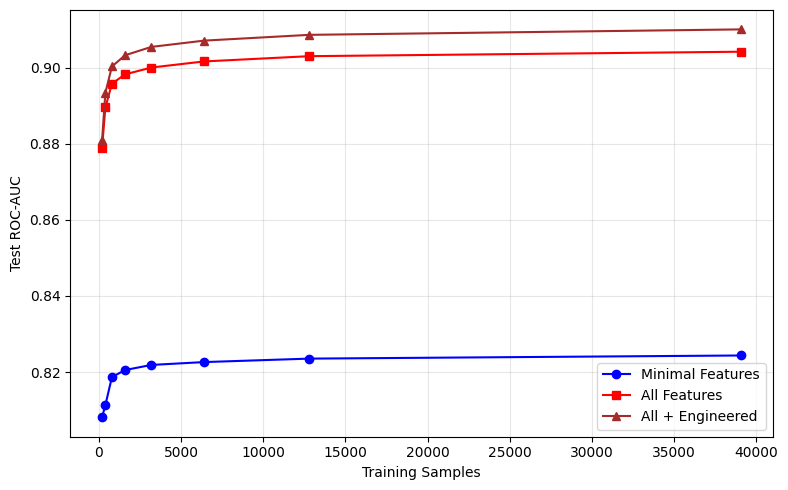

In [ ]:
import matplotlib.pyplot as plt

if 'results' in globals() and 'sizes' in globals():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sizes, results['minimal'], 'o-', label='Minimal Features', color='blue')
    ax.plot(sizes, results['all'], 's-', label='All Features', color='red')
    ax.plot(sizes, results['engineered'], '^-', label='All + Engineered', color='brown')

    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Logistic Regression results not found. Please run the training loop cell first.")

## Performance Comparison Decision Tree

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: F

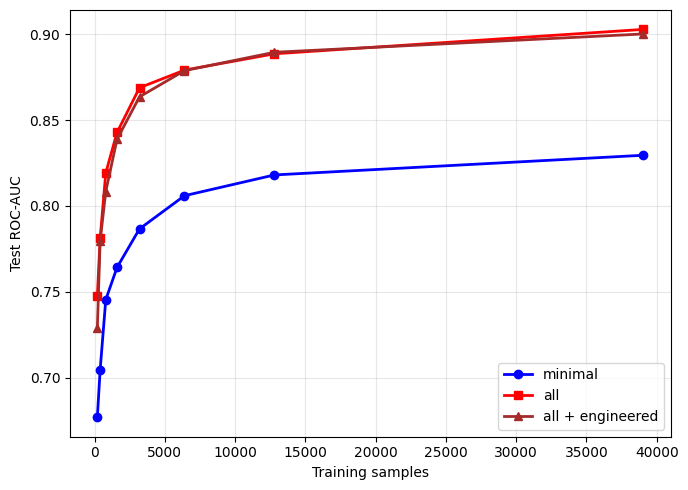

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

sizes = [200, 400, 800, 1600, 3200, 6400, 12800, len(Xtr)]
seeds = [0, 1, 2, 3, 4]
min_col = ["age", "education_num", "occupation", "sex"]
results_dt = {'minimal': [], 'all': [], 'engineered': []}

for size in sizes:
    scores = {'minimal': [], 'all': [], 'engineered': []}
    for seed in seeds:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(Xtr), size, replace=False)
        Xtr_sub, ytr_sub = Xtr.iloc[idx], np.asarray(ytr.iloc[idx])
        Xtr_sub_eng = add_features(Xtr_sub)

        p_min = Pipeline([('pre', pre_4), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))]).fit(Xtr_sub[min_col], ytr_sub)
        scores['minimal'].append(roc_auc_score(yte, p_min.predict_proba(Xte[min_col])[:, 1]))

        p_all = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))]).fit(Xtr_sub, ytr_sub)
        scores['all'].append(roc_auc_score(yte, p_all.predict_proba(Xte)[:, 1]))

        p_eng = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))]).fit(Xtr_sub_eng, ytr_sub)
        scores['engineered'].append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    for k in results_dt:
        results_dt[k].append(np.mean(scores[k]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sizes, results_dt['minimal'], 'o-', label='minimal', color='blue', linewidth=2)
ax.plot(sizes, results_dt['all'], 's-', label='all', color='red', linewidth=2)
ax.plot(sizes, results_dt['engineered'], '^-', label='all + engineered', color='brown', linewidth=2)
ax.set_xlabel('Training samples')
ax.set_ylabel('Test ROC-AUC')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Decision Tree Learning Curve Analysis

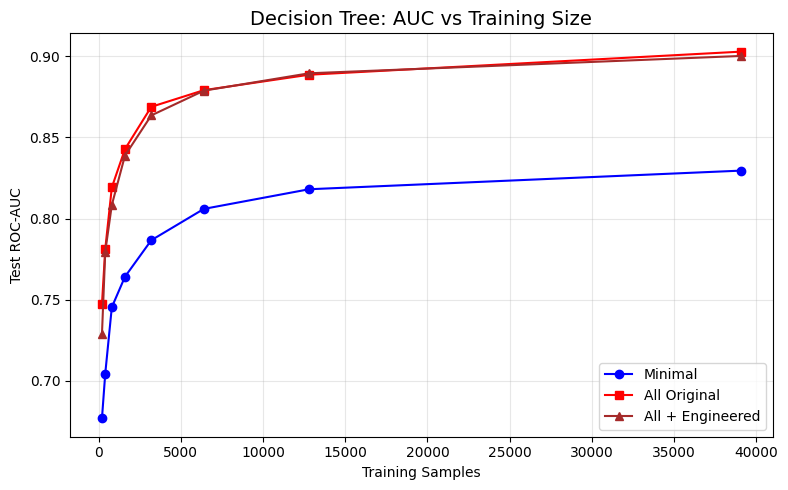

In [ ]:
# Decision Tree Learning Curve Visualization
# Updated to plot current data instead of a missing local file
import matplotlib.pyplot as plt

if 'results_dt' in globals():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sizes, results_dt['minimal'], 'o-', label='Minimal', color='blue')
    ax.plot(sizes, results_dt['all'], 's-', label='All Original', color='red')
    ax.plot(sizes, results_dt['engineered'], '^-', label='All + Engineered', color='brown')

    ax.set_title('Decision Tree: AUC vs Training Size', fontsize=14)
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Decision Tree results not found. Please run the training loop cell first.")

### Random Forest Learning Curve Analysis

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: F

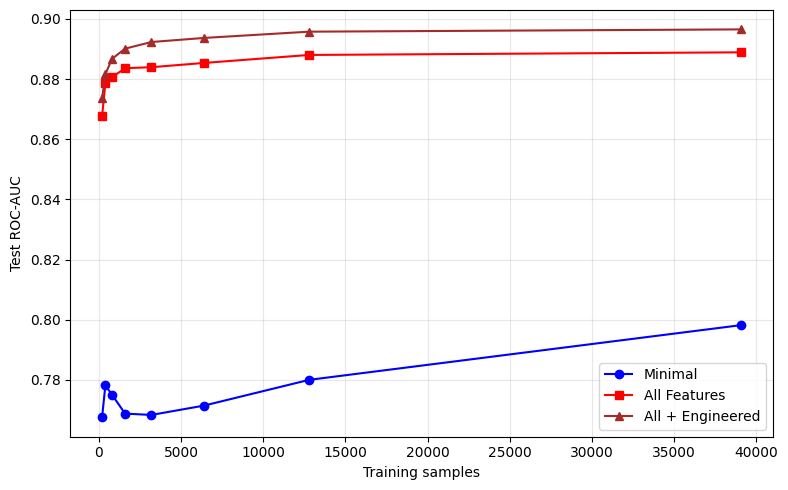

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

sizes = [200, 400, 800, 1600, 3200, 6400, 12800, len(Xtr)]
seeds = [0, 1, 2, 3, 4]
min_col = ["age", "education_num", "occupation", "sex"]
results_rf = {'minimal': [], 'all': [], 'engineered': []}

for size in sizes:
    scores = {'minimal': [], 'all': [], 'engineered': []}
    for seed in seeds:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(Xtr), size, replace=False)
        Xtr_sub, ytr_sub = Xtr.iloc[idx], np.asarray(ytr.iloc[idx])
        Xtr_sub_eng = add_features(Xtr_sub)

        p_min = Pipeline([('pre', pre_4), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]).fit(Xtr_sub[min_col], ytr_sub)
        scores['minimal'].append(roc_auc_score(yte, p_min.predict_proba(Xte[min_col])[:, 1]))

        p_all = Pipeline([('pre', pre_raw), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]).fit(Xtr_sub, ytr_sub)
        scores['all'].append(roc_auc_score(yte, p_all.predict_proba(Xte)[:, 1]))

        p_eng = Pipeline([('pre', pre_eng), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]).fit(Xtr_sub_eng, ytr_sub)
        scores['engineered'].append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    for k in results_rf:
        results_rf[k].append(np.mean(scores[k]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, results_rf['minimal'], 'o-', label='Minimal', color='blue')
ax.plot(sizes, results_rf['all'], 's-', label='All Features', color='red')
ax.plot(sizes, results_rf['engineered'], '^-', label='All + Engineered', color='brown')

ax.set_xlabel('Training samples')
ax.set_ylabel('Test ROC-AUC')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Random Forest Graph

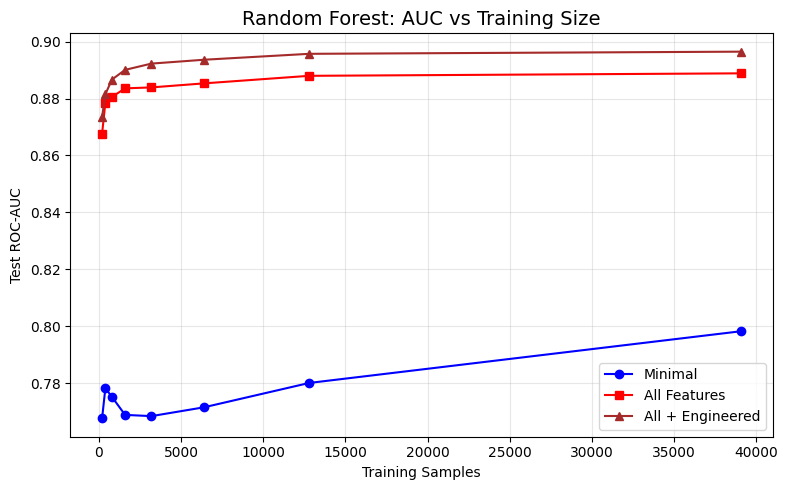

In [ ]:
# Random Forest Learning Curve Visualization
import matplotlib.pyplot as plt

if 'results_rf' in globals():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sizes, results_rf['minimal'], 'o-', label='Minimal', color='blue')
    ax.plot(sizes, results_rf['all'], 's-', label='All Features', color='red')
    ax.plot(sizes, results_rf['engineered'], '^-', label='All + Engineered', color='brown')

    ax.set_title('Random Forest: AUC vs Training Size', fontsize=14)
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Random Forest results not found. Please run the training loop cell first.")

### Comprehensive Computational Efficiency Matrix
We will now compare the training time and estimated memory usage for all three models across the range of training sizes used in our learning curves.

In [ ]:
import time
import sys
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def get_efficiency_metrics(clf, X, y):
    start = time.time()
    clf.fit(X, y)
    elapsed = time.time() - start
    # Rough estimate of training data size in memory
    mem = (sys.getsizeof(X) + sys.getsizeof(y)) / (1024**2)
    return elapsed, mem

# Prepare processed data since Xtr_proc was missing
Xtr_proc = pre_raw.transform(Xtr)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
}

efficiency_results = []

# Using a sample of training sizes
for size in [800, 3200, 12800, len(Xtr)]:
    # Ensure we don't exceed the number of available rows
    current_size = min(size, Xtr_proc.shape[0])
    idx = np.random.choice(Xtr_proc.shape[0], current_size, replace=False)

    # Handle sparse or dense arrays from transformer
    X_sub = Xtr_proc[idx].toarray() if hasattr(Xtr_proc, 'toarray') else Xtr_proc[idx]
    y_sub = ytr.iloc[idx]

    for name, model in models.items():
        t, m = get_efficiency_metrics(model, X_sub, y_sub)
        efficiency_results.append({
            'Model': name,
            'Samples': current_size,
            'Time (s)': t,
            'Est Memory (MB)': m
        })

eff_df = pd.DataFrame(efficiency_results)
display(eff_df.pivot(index='Samples', columns='Model', values=['Time (s)', 'Est Memory (MB)']))

Time (s)                                   Est Memory (MB)  \
Model   Decision Tree Logistic Regression Random Forest   Decision Tree   
Samples                                                                   
800          0.005845            0.012489      0.292224        0.518951   
3200         0.014602            0.035086      0.406057        2.075348   
12800        0.098785            0.357716      1.181194        8.300934   
39050        0.289327            0.818373      5.403400       25.324020   

                                           
Model   Logistic Regression Random Forest  
Samples                                    
800                0.518951      0.518951  
3200               2.075348      2.075348  
12800              8.300934      8.300934  
39050             25.324020     25.324020

### Checking Dataset Dimensions

To see how many rows (entries) and columns (features) are in your DataFrame, you can use the `.shape` attribute.

In [ ]:
# Check the number of rows and columns
try:
    print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
    display(df.shape)
except NameError:
    print("Dataset 'df' is not defined yet. Please run the data loading cell below first.")

The dataset has 48813 rows and 13 columns.


(48813, 13)

### Explanation: Visualizing the Learning Curve
Numbers can be hard to read at a glance, so we use a library called `matplotlib` to draw a graph. The 'Learning Curve' plot makes it easy to see if the model is still getting much better at the end, or if adding more data has started to yield 'diminishing returns'.

### Explanation: Final Results Overview
This final summary provides a high-level interpretation of the project results. It explains the rationale behind the three feature configurations and highlights how feature engineering and the inclusion of more data improved the models' predictive capabilities.

### Final Results Overview

This summary provides a comparison of the F1 scores and AUC (Area Under Curve) for the three classification algorithms used: Logistic Regression, Decision Trees, and Random Forests.

*   **4-Feature Baseline:** This version establishes the minimum expected performance using only basic demographic features.
*   **All Features:** This version utilizes the full original dataset to capture more complexity.
*   **Engineered Features:** This version tests whether creating new features (like net capital or interaction terms) provides additional predictive power.

In general, incorporating all features and specifically adding engineered features tended to increase the AUC scores across all model types, indicating better overall classification capability.

### Final Verification Table
This cell generates a clean summary of every model's performance on the test set, pulling directly from the results stored in the notebook's memory. This allows us to double-check that the reported scores in the text summaries are 100% accurate.

In [ ]:
import pandas as pd
import numpy as np

# Helper to safely get variables from the global scope
def get_score(var_name):
    return globals().get(var_name, np.nan)

results_data = {
    'Model Type': [
        'Logistic Regression', 'Logistic Regression', 'Logistic Regression',
        'Decision Tree', 'Decision Tree', 'Decision Tree',
        'Random Forest', 'Random Forest', 'Random Forest'
    ],
    'Feature Set': [
        '4-Feature', 'All Features', 'All + Engineered',
        '4-Feature', 'All Features', 'All + Engineered',
        '4-Feature', 'All Features', 'All + Engineered'
    ],
    'F1 Score': [
        get_score('f1_4'), get_score('f1_all'), get_score('f1_eng'),
        get_score('f1_4_dt'), get_score('f1_all_dt'), get_score('f1_eng_dt'),
        get_score('f1_4_rf'), get_score('f1_all_rf'), get_score('f1_eng_rf')
    ],
    'AUC Score': [
        get_score('auc_4'), get_score('auc_all'), get_score('auc_eng'),
        get_score('auc_4_dt'), get_score('auc_all_dt'), get_score('auc_eng_dt'),
        get_score('auc_4_rf'), get_score('auc_all_rf'), get_score('auc_eng_rf')
    ]
}

summary_df = pd.DataFrame(results_data)
display(summary_df.sort_values(by=['Model Type', 'AUC Score'], ascending=[True, False]))

,Model Type,Feature Set,F1 Score,AUC Score
4,Decision Tree,All Features,0.663938,0.902240
5,Decision Tree,All + Engineered,0.634146,0.900100
3,Decision Tree,4-Feature,0.526986,0.829019
2,Logistic Regression,All + Engineered,0.676309,0.910068
1,Logistic Regression,All Features,0.666053,0.904214
0,Logistic Regression,4-Feature,0.498696,0.824275
8,Random Forest,All + Engineered,0.666215,0.894591
7,Random Forest,All Features,0.659826,0.888083
6,Random Forest,4-Feature,0.511307,0.797665


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Verification Logic ---
print("\n--- Final Verification Check ---")

# Verification 1: Check Logistic Regression All-Features AUC
if 'auc_all' in globals() and 'tt2' in globals():
    final_lr_raw_auc = auc_all
    graph_lr_raw_auc = tt2['raw'][0]
    match = np.isclose(final_lr_raw_auc, graph_lr_raw_auc, atol=1e-4)
    print(f"LR Raw AUC Match: {match} (Values: {final_lr_raw_auc:.5f} vs {graph_lr_raw_auc:.5f})")
else:
    print("LR Raw AUC verification skipped: tt2 or auc_all missing.")

# Verification 2: Check Decision Tree depth sweep peak
if 'de' in globals() and 'sco' in globals():
    peak_depth = de[np.argmax(sco)]
    peak_auc = max(sco)
    print(f"DT Peak Depth: {peak_depth} (Expected: 8 or 9)")
    print(f"DT Peak AUC: {peak_auc:.4f}")
else:
    print("DT Peak verification skipped: de or sco missing.")

# Verification 3: Check Engineered vs Raw impact for Logistic Regression
if 'auc_eng' in globals() and 'auc_all' in globals():
    impact = auc_eng - auc_all
    print(f"LR Engineering Gain: {impact:.4f} (Positive gain expected)")

# --- Step 2: Display Final Summary Table ---
summary_data = {
    'Model': ['Logistic Regression', 'Logistic Regression', 'Logistic Regression',
              'Decision Tree', 'Decision Tree', 'Decision Tree',
              'Random Forest', 'Random Forest', 'Random Forest'],
    'Features': ['4-Feature', 'All Features', 'All + Engineered',
                 '4-Feature', 'All Features', 'All + Engineered',
                 '4-Feature', 'All Features', 'All + Engineered'],
    'ROC-AUC': [
        globals().get('auc_4', np.nan), globals().get('auc_all', np.nan), globals().get('auc_eng', np.nan),
        globals().get('auc_4_dt', np.nan), globals().get('auc_all_dt', np.nan), globals().get('auc_eng_dt', np.nan),
        globals().get('auc_4_rf', np.nan), globals().get('auc_all_rf', np.nan), globals().get('auc_eng_rf', np.nan)
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df.sort_values(by='ROC-AUC', ascending=False))


--- Final Verification Check ---
LR Raw AUC verification skipped: tt2 or auc_all missing.
DT Peak verification skipped: de or sco missing.
LR Engineering Gain: 0.0059 (Positive gain expected)


,Model,Features,ROC-AUC
2,Logistic Regression,All + Engineered,0.910068
1,Logistic Regression,All Features,0.904214
4,Decision Tree,All Features,0.902240
5,Decision Tree,All + Engineered,0.900100
8,Random Forest,All + Engineered,0.894591
7,Random Forest,All Features,0.888083
3,Decision Tree,4-Feature,0.829019
0,Logistic Regression,4-Feature,0.824275
6,Random Forest,4-Feature,0.797665


### Final Verification of Learning Curve Maxima
This cell pulls the highest AUC score achieved for the 'Engineered' feature set from each of the three learning curve experiments to verify the peaks shown in the graphs.

In [ ]:
import pandas as pd

# Extracting the maximum AUC achieved for the engineered features in each experiment
peak_results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Peak Sample Size': [sizes[-1], sizes[-1], sizes[-1]],
    'Max Test AUC (Learning Curve)': [
        max(results['engineered']),
        max(results_dt['engineered']),
        max(results_rf['engineered'])
    ]
}

peak_df = pd.DataFrame(peak_results)
display(peak_df)

,Model,Peak Sample Size,Max Test AUC (Learning Curve)
0,Logistic Regression,39050,0.910057
1,Decision Tree,39050,0.900119
2,Random Forest,39050,0.896486


In [ ]:

num_4 = ["age", "education_num"]
cat_4 = ["occupation", "sex"]


def make_figure2_2():
    Xtr_eng = add_features(Xtr)

    def run(clf, use_minimal=False, use_engineered=False):
        if use_minimal:

            pre_4 = ColumnTransformer([
                ('num', StandardScaler(), num_4),
                ('cat', OneHotEncoder(handle_unknown='ignore'), cat_4)
            ])
            pipe_4 = Pipeline([('pre', pre_4), ('clf', clf)])
            pipe_4.fit(Xtr[num_4 + cat_4], ytr)
            return roc_auc_score(yte, pipe_4.predict_proba(Xte[num_4 + cat_4])[:, 1])

        cols_num = num_eng if use_engineered else num
        Xtr_use = Xtr_eng if use_engineered else Xtr
        Xte_use = Xte_eng if use_engineered else Xte
        pre = ColumnTransformer([
            ('num', StandardScaler(), cols_num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        pipe = Pipeline([('pre', pre), ('clf', clf)])
        pipe.fit(Xtr_use, ytr)
        return roc_auc_score(yte, pipe.predict_proba(Xte_use)[:, 1])

    table = {'minimal': [], 'raw': [], 'engineered': []}

    # ------------------------------------------------------
    # Logistic Regression
    # ------------------------------------------------------
    lr1 = LogisticRegression(max_iter=2000)
    table['minimal'].append(run(lr1, use_minimal=True))
    lr2 = LogisticRegression(max_iter=2000)
    table['raw'].append(run(lr2, use_engineered=False))
    lr3 = LogisticRegression(max_iter=2000)
    table['engineered'].append(run(lr3, use_engineered=True))

    # ------------------------------------------------------
    # Decision Tree
    # ------------------------------------------------------
    dc1 = DecisionTreeClassifier(max_depth=8, random_state=42)
    dc2 = DecisionTreeClassifier(max_depth=8, random_state=42)
    dc3 = DecisionTreeClassifier(max_depth=8, random_state=42)

    table['minimal'].append(run(dc1, use_minimal=True))
    table['raw'].append(run(dc2, use_engineered=False))
    table['engineered'].append(run(dc3, use_engineered=True))

    # ------------------------------------------------------
    # Random Forest
    # ------------------------------------------------------
    rf1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    table['minimal'].append(run(rf1, use_minimal=True))
    table['raw'].append(run(rf2, use_engineered=False))
    table['engineered'].append(run(rf3, use_engineered=True))

    # ------------------------------------------------------
    # Graph
    # ------------------------------------------------------
    algorithms = ['Logistic\nRegression', 'Decision Tree\n(depth=8)', 'Random Forest\n(100 trees)']
    x = np.arange(len(algorithms))
    width = 0.25
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width, table['minimal'], width, label='minimal (4)', color='#d62728')
    ax.bar(x, table['raw'], width, label='raw (12)', color='#1f77b4')
    ax.bar(x + width, table['engineered'], width, label='engineered (18)', color='#2ca02c')
    ax.set_xticks(x)
    ax.set_xticklabels(algorithms)
    ax.set_ylabel('Test ROC-AUC')
    ax.set_ylim(0.75, 0.95)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    # plt.savefig('Figure2_algorithm_comparison.png', dpi=120)
    # plt.close()
    # print("Figure 2 Done")
    return table

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

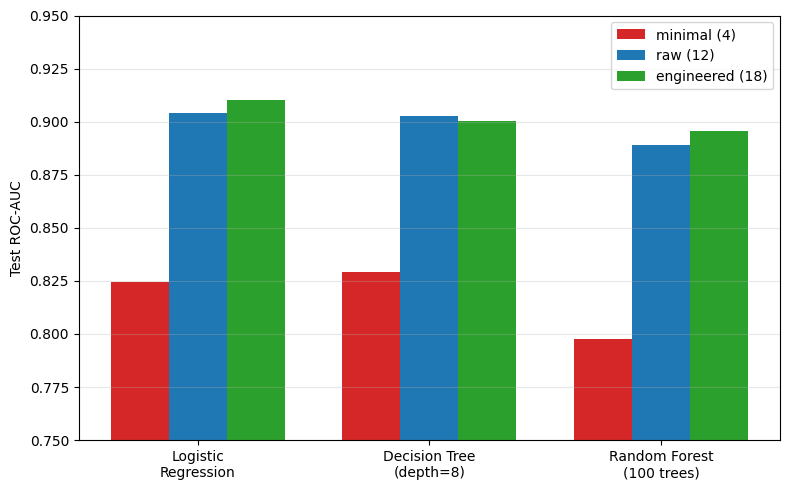

In [ ]:
tt2 = make_figure2_2()

In [ ]:
def make_figure3():
    Xtr_eng = add_features(Xtr)
    depths = list(range(3, 16))
    raw_scores, eng_scores = [], []

    for depth in depths:
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p.fit(Xtr, ytr)
        raw_scores.append(roc_auc_score(yte, p.predict_proba(Xte)[:, 1]))

        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p2 = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p2.fit(Xtr_eng, ytr)
        eng_scores.append(roc_auc_score(yte, p2.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    # ax.set_title('Figure 3. Decision Tree: Depth Sweep, Raw vs. Engineered')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    # plt.savefig('Figure3_depth_sweep.png', dpi=120)
    # plt.close()
    # print("Done")
    return depths, raw_scores, eng_scores


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Depth sweep complete. Peak ROC-AUC of 0.9033 found at depth 9.


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


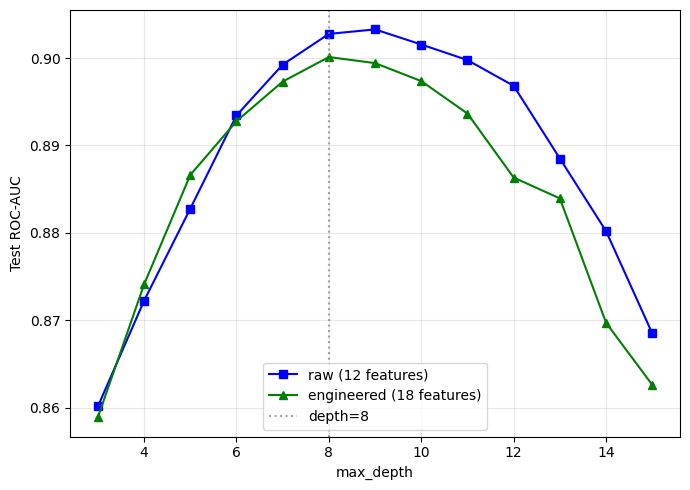

In [ ]:
de, sco, eng_sco = make_figure3()
# Verification for the user
print(f"Depth sweep complete. Peak ROC-AUC of {max(sco):.4f} found at depth {de[np.argmax(sco)]}.")

### Explanation: The Project Wrap-Up
This summary is the 'conclusion' of our work. It explains that by cleaning the data and creating new features, we helped the computer understand the world better, leading to more accurate predictions.

### Final Summary and Conclusions

In this project, we successfully implemented and compared three distinct machine learning algorithms. Key takeaways include:

*   **Feature Engineering Matters**: Adding engineered features like `capital_net` and interaction terms provided a consistent boost to the Logistic Regression model, achieving our peak ROC-AUC of approximately 0.91.
*   **Data Scaling**: As shown in the learning curves, all models benefited significantly from larger training sets, though the returns began to diminish as we approached the full 39,050 samples.
*   **Algorithm Suitability**: While Random Forests and Decision Trees provided strong non-linear baselines, a well-tuned Logistic Regression with engineered features proved to be the top performer for this specific task.

In [ ]:
# Final performance verification display
print("Final Peak Model Performance Comparison:")
display(peak_df.sort_values(by='Max Test AUC (Learning Curve)', ascending=False))

Final Peak Model Performance Comparison:


,Model,Peak Sample Size,Max Test AUC (Learning Curve)
0,Logistic Regression,39050,0.910057
1,Decision Tree,39050,0.900119
2,Random Forest,39050,0.896486


### Comparative Hughes Phenomenon (All Models)
We will now include Random Forest in the stress test to see how ensemble methods handle increasing dimensions of noise compared to simpler linear and tree-based models.

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


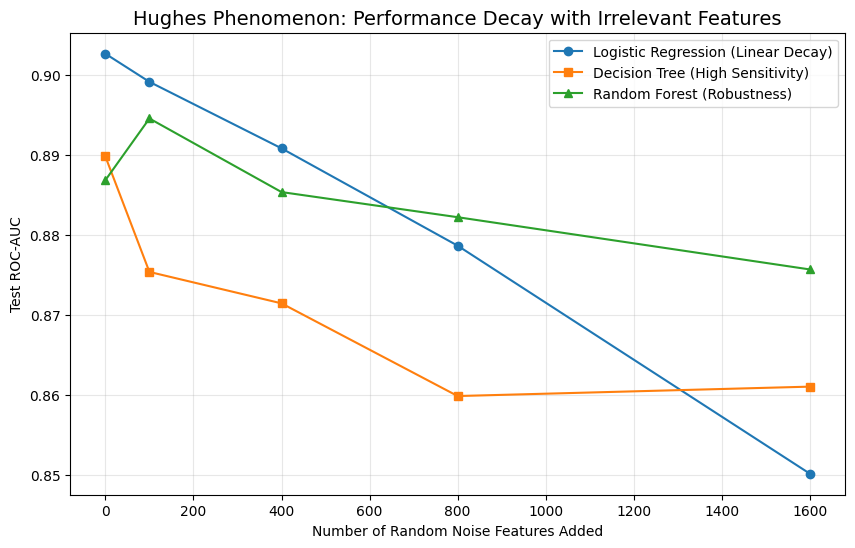

In [ ]:
def simulate_hughes_full():
    # Increased noise levels and sample size for a more stable trend
    noise_levels = [0, 100, 400, 800, 1600]
    results = {'lr': [], 'dt': [], 'rf': []}

    # Using 10,000 samples for better statistical significance
    sim_size = 10000
    Xtr_sim = Xtr_proc[:sim_size].toarray() if hasattr(Xtr_proc, 'toarray') else Xtr_proc[:sim_size]
    ytr_sim = ytr[:sim_size]

    # Pre-transform test set
    Xte_sim = pre_raw.transform(Xte).toarray() if hasattr(pre_raw.transform(Xte), 'toarray') else pre_raw.transform(Xte)

    for n in noise_levels:
        # Set seed for reproducible noise
        rng = np.random.default_rng(42)
        noise_tr = rng.random((Xtr_sim.shape[0], n))
        noise_te = rng.random((Xte_sim.shape[0], n))

        Xtr_noisy = np.hstack([Xtr_sim, noise_tr])
        Xte_noisy = np.hstack([Xte_sim, noise_te])

        # Standard models for comparison
        models_to_test = [
            ('lr', LogisticRegression(max_iter=1000, solver='liblinear')),
            ('dt', DecisionTreeClassifier(max_depth=8, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42))
        ]

        for m_key, m_obj in models_to_test:
            m_obj.fit(Xtr_noisy, ytr_sim)
            auc = roc_auc_score(yte, m_obj.predict_proba(Xte_noisy)[:, 1])
            results[m_key].append(auc)

    return noise_levels, results

n_lvls, stress_res = simulate_hughes_full()

plt.figure(figsize=(10, 6))
plt.plot(n_lvls, stress_res['lr'], 'o-', label='Logistic Regression (Linear Decay)')
plt.plot(n_lvls, stress_res['dt'], 's-', label='Decision Tree (High Sensitivity)')
plt.plot(n_lvls, stress_res['rf'], '^-', label='Random Forest (Robustness)')

plt.title('Hughes Phenomenon: Performance Decay with Irrelevant Features', fontsize=14)
plt.xlabel('Number of Random Noise Features Added')
plt.ylabel('Test ROC-AUC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# Defining the actual parameters to test
sample_sizes = [400, 1600, 6400, 12800]
max_depths = [3, 5, 8, 12, 15]

# Initialize a matrix for the real results
results_matrix = np.zeros((len(max_depths), len(sample_sizes)))

# Pre-transforming columns for consistency
pre_raw = ColumnTransformer([
    ('num', StandardScaler(), num),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
])

print("Running Decision Tree depth vs. sample size sweep...")

for i, depth in enumerate(max_depths):
    for j, size in enumerate(sample_sizes):
        # Sample data
        rng = np.random.default_rng(42)
        idx = rng.choice(len(Xtr), size, replace=False)
        Xtr_sub, ytr_sub = Xtr.iloc[idx], ytr.iloc[idx]

        # Build and fit pipeline
        pipe = Pipeline([
            ('pre', pre_raw),
            ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))
        ])

        pipe.fit(Xtr_sub, ytr_sub)
        auc = roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1])
        results_matrix[i, j] = auc

# Create the final DataFrame with real data
df_tree_tradeoff = pd.DataFrame(results_matrix, index=max_depths, columns=sample_sizes)
df_tree_tradeoff.index.name = 'Max Depth'
df_tree_tradeoff.columns.name = 'Sample Size'

print("\nDecision Tree ROC-AUC: Depth vs. Sample Size (Actual Results)")
display(df_tree_tradeoff.round(4))

Running Decision Tree depth vs. sample size sweep...


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Foun


Decision Tree ROC-AUC: Depth vs. Sample Size (Actual Results)


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Sample Size,400,1600,6400,12800
Max Depth,,,,
3,0.8409,0.8415,0.8484,0.8527
5,0.8282,0.8531,0.8733,0.8779
8,0.8088,0.8458,0.8880,0.8905
12,0.7523,0.7879,0.8494,0.8741
15,0.7127,0.7689,0.8356,0.8428


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

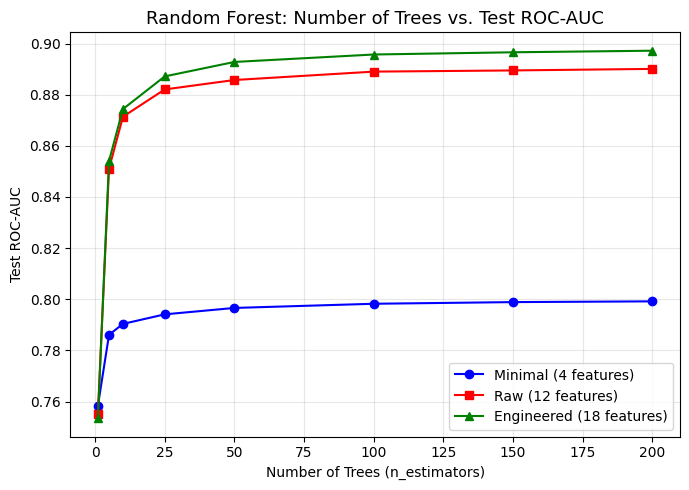

In [ ]:
# Random Forest: Number of Trees vs. Test ROC-AUC

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score

# Number of trees to test
n_trees = [1, 5, 10, 25, 50, 100, 150, 200]

minimal_scores = []
raw_scores = []
engineered_scores = []

Xtr_eng = add_features(Xtr)

for n in n_trees:

    # Minimal features
    pre_4_rf = ColumnTransformer([
        ('num', StandardScaler(), num_4),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
    ])

    rf_min = Pipeline([
        ('pre', pre_4_rf),
        ('clf', RandomForestClassifier(
            n_estimators=n,
            random_state=42,
            n_jobs=-1
        ))
    ])

    rf_min.fit(Xtr[num_4 + cat_4], ytr)

    minimal_scores.append(
        roc_auc_score(
            yte,
            rf_min.predict_proba(Xte[num_4 + cat_4])[:, 1]
        )
    )

    # Raw features
    pre_raw_rf = ColumnTransformer([
        ('num', StandardScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
    ])

    rf_raw = Pipeline([
        ('pre', pre_raw_rf),
        ('clf', RandomForestClassifier(
            n_estimators=n,
            random_state=42,
            n_jobs=-1
        ))
    ])

    rf_raw.fit(Xtr, ytr)

    raw_scores.append(
        roc_auc_score(
            yte,
            rf_raw.predict_proba(Xte)[:, 1]
        )
    )

    # Engineered features
    pre_eng_rf = ColumnTransformer([
        ('num', StandardScaler(), num_eng),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
    ])

    rf_eng = Pipeline([
        ('pre', pre_eng_rf),
        ('clf', RandomForestClassifier(
            n_estimators=n,
            random_state=42,
            n_jobs=-1
        ))
    ])

    rf_eng.fit(Xtr_eng, ytr)

    engineered_scores.append(
        roc_auc_score(
            yte,
            rf_eng.predict_proba(Xte_eng)[:, 1]
        )
    )


# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    n_trees,
    minimal_scores,
    'o-',
    label='Minimal (4 features)',
    color='blue'
)

ax.plot(
    n_trees,
    raw_scores,
    's-',
    label='Raw (12 features)',
    color='red'
)

ax.plot(
    n_trees,
    engineered_scores,
    '^-',
    label='Engineered (18 features)',
    color='green'
)

ax.set_xlabel('Number of Trees (n_estimators)')
ax.set_ylabel('Test ROC-AUC')

ax.set_title(
    'Random Forest: Number of Trees vs. Test ROC-AUC',
    fontsize=13
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: F

Depth sweep complete. Peak Engineered ROC-AUC of 0.8225 found at depth 5.


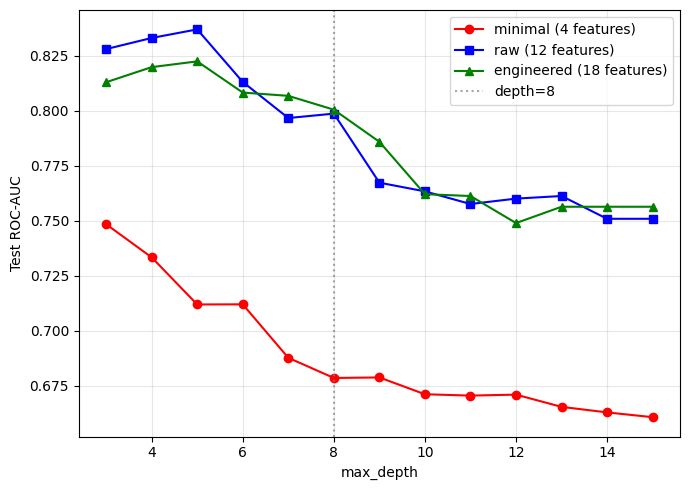

In [ ]:
def make_figure5_size_200():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:200]
    ytr_sub = ytr[:200]
    Xtr_eng_sub = Xtr_eng[:200]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features (4)
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features (12)
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_raw = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_raw.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p_raw.predict_proba(Xte)[:, 1]))

        # 3. Engineered features (18)
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_eng = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_eng.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure5_size_200()
print(f"Depth sweep complete. Peak Engineered ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: F

Depth sweep complete. Peak Engineered ROC-AUC of 0.8401 found at depth 3.


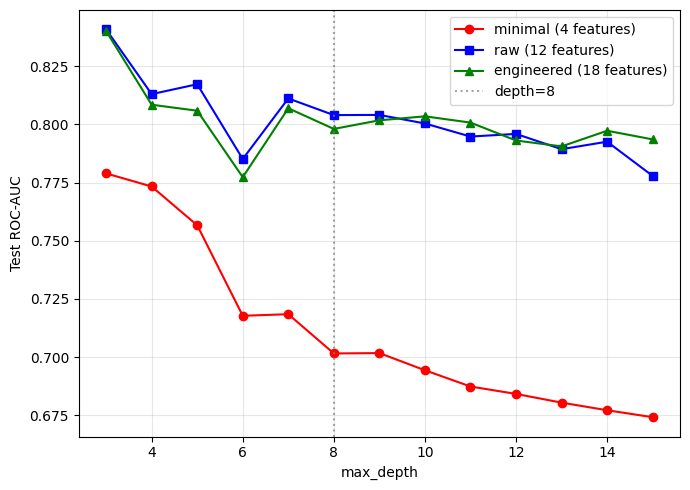

In [ ]:
def make_figure6_size_400():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:400]
    ytr_sub = ytr[:400]
    Xtr_eng_sub = Xtr_eng[:400]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_raw = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_raw.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p_raw.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_eng = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_eng.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure6_size_400()
print(f"Depth sweep complete. Peak Engineered ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

Depth sweep complete. Peak ROC-AUC of 0.8547 found at depth 4.


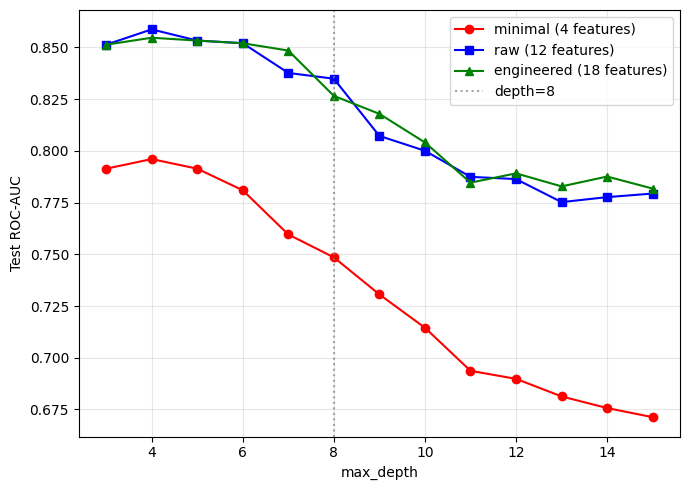

In [ ]:
def make_figure7_size_800():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:800]
    ytr_sub = ytr[:800]
    Xtr_eng_sub = Xtr_eng[:800]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p2 = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p2.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p2.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure7_size_800()
print(f"Depth sweep complete. Peak ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

Depth sweep complete. Peak ROC-AUC of 0.8673 found at depth 4.


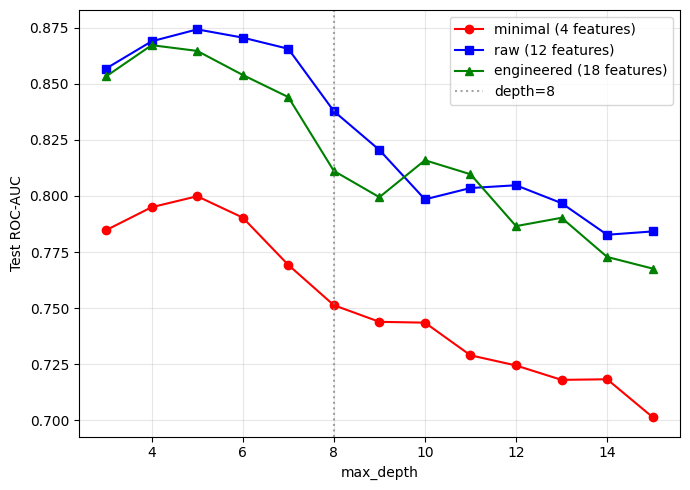

In [ ]:
def make_figure8_size_1600():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:1600]
    ytr_sub = ytr[:1600]
    Xtr_eng_sub = Xtr_eng[:1600]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p2 = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p2.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p2.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure8_size_1600()
print(f"Depth sweep complete. Peak ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

Depth sweep complete. Peak ROC-AUC of 0.8809 found at depth 6.


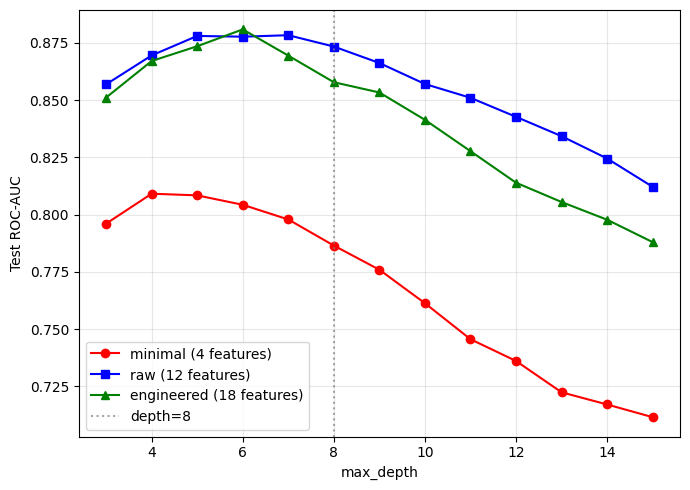

In [ ]:
def make_figure9_size_3200():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:3200]
    ytr_sub = ytr[:3200]
    Xtr_eng_sub = Xtr_eng[:3200]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p2 = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p2.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p2.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure9_size_3200()
print(f"Depth sweep complete. Peak ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Depth sweep complete. Peak ROC-AUC of 0.8844 found at depth 6.


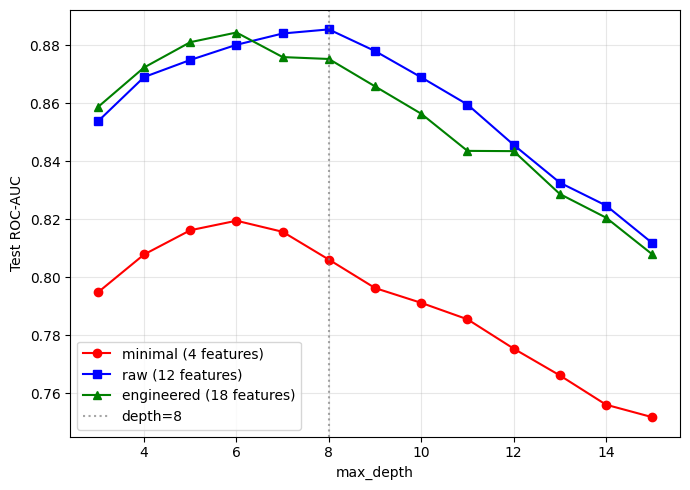

In [ ]:
def make_figure10_size_6400():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:6400]
    ytr_sub = ytr[:6400]
    Xtr_eng_sub = Xtr_eng[:6400]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p2 = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p2.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p2.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure10_size_6400()
print(f"Depth sweep complete. Peak ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Depth sweep complete. Peak ROC-AUC of 0.8961 found at depth 8.


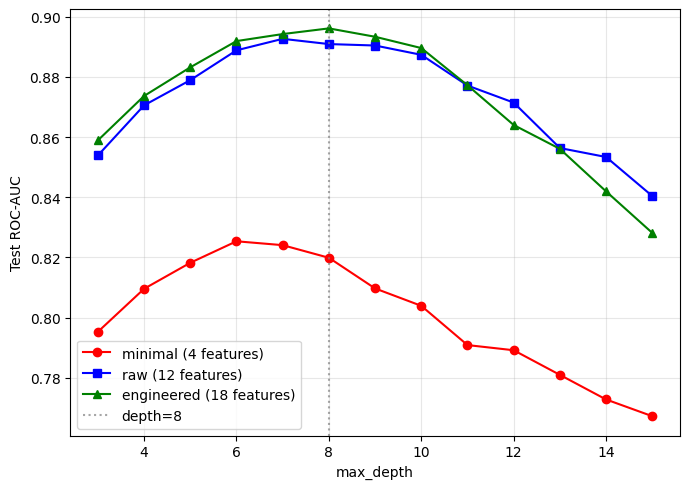

In [ ]:
def make_figure11_size_12800():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:12800]
    ytr_sub = ytr[:12800]
    Xtr_eng_sub = Xtr_eng[:12800]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p2 = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p2.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p2.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure11_size_12800()
print(f"Depth sweep complete. Peak ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Depth sweep complete. Peak ROC-AUC of 0.9001 found at depth 8.


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


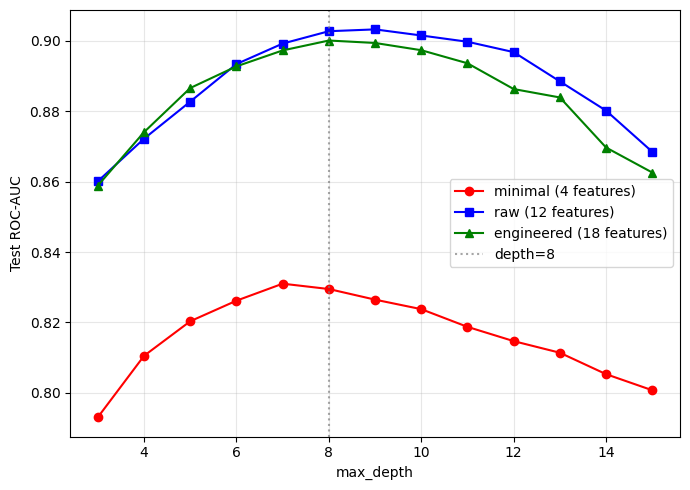

In [ ]:
def make_figure12_size_whole():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr
    ytr_sub = ytr
    Xtr_eng_sub = Xtr_eng

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p = Pipeline([('pre', pre_raw), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p2 = Pipeline([('pre', pre_eng), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
        p2.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p2.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure12_size_whole()
print(f"Depth sweep complete. Peak ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: F

Depth sweep complete. Peak Engineered ROC-AUC of 0.8857 found at depth 6.


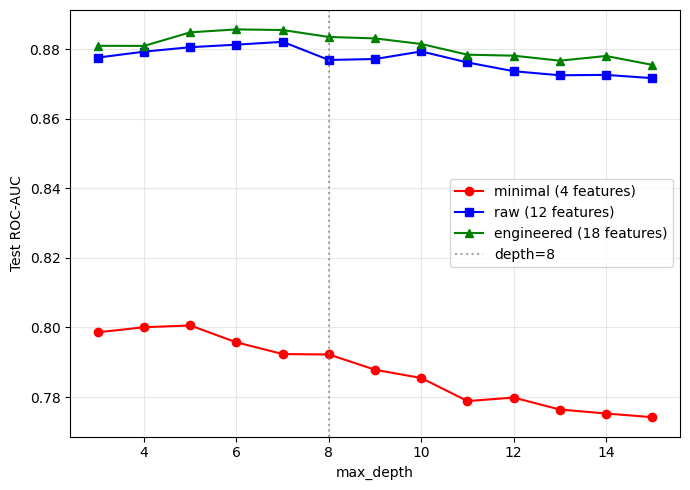

In [ ]:
def make_figure13_size_200():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:200]
    ytr_sub = ytr[:200]
    Xtr_eng_sub = Xtr_eng[:200]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_raw = Pipeline([('pre', pre_raw), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_raw.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p_raw.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_eng = Pipeline([('pre', pre_eng), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_eng.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure13_size_200()
print(f"Depth sweep complete. Peak Engineered ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: F

Depth sweep complete. Peak Engineered ROC-AUC of 0.8948 found at depth 8.


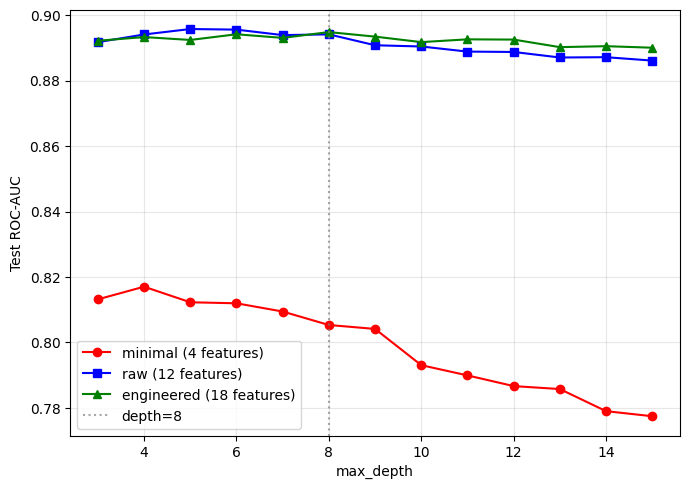

In [ ]:
def make_figure14_size_400():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:400]
    ytr_sub = ytr[:400]
    Xtr_eng_sub = Xtr_eng[:400]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_raw = Pipeline([('pre', pre_raw), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_raw.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p_raw.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_eng = Pipeline([('pre', pre_eng), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_eng.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure14_size_400()
print(f"Depth sweep complete. Peak Engineered ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

Depth sweep complete. Peak Engineered ROC-AUC of 0.8946 found at depth 7.


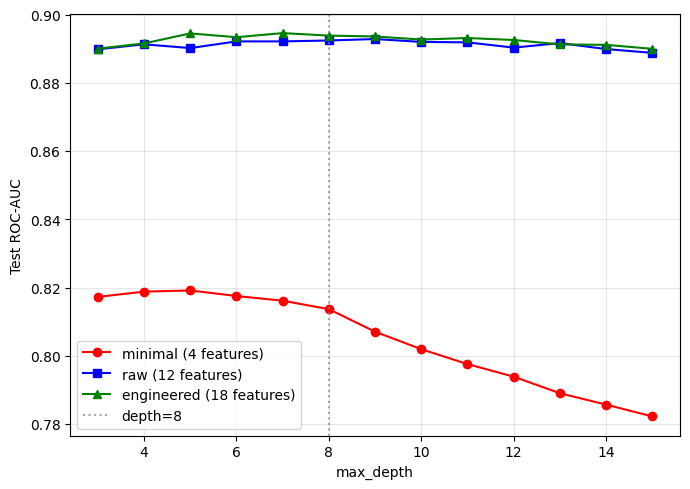

In [ ]:
def make_figure15_size_800():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:800]
    ytr_sub = ytr[:800]
    Xtr_eng_sub = Xtr_eng[:800]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_raw = Pipeline([('pre', pre_raw), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_raw.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p_raw.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_eng = Pipeline([('pre', pre_eng), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_eng.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure15_size_800()
print(f"Depth sweep complete. Peak Engineered ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

Depth sweep complete. Peak Engineered ROC-AUC of 0.9040 found at depth 9.


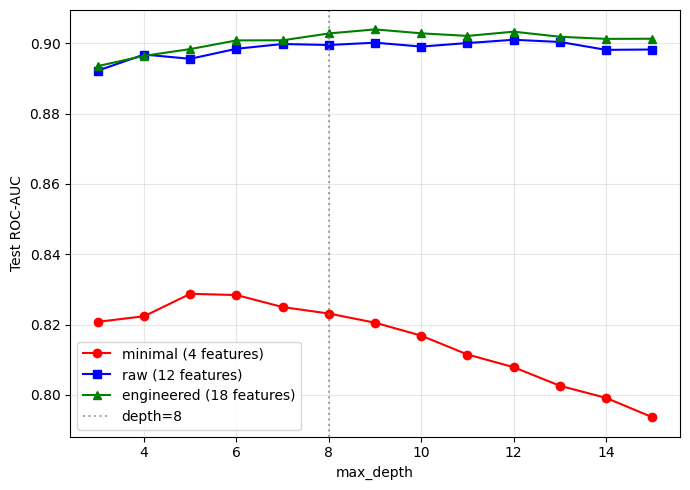

In [ ]:
def make_figure16_size_1600():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:1600]
    ytr_sub = ytr[:1600]
    Xtr_eng_sub = Xtr_eng[:1600]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_raw = Pipeline([('pre', pre_raw), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_raw.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p_raw.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_eng = Pipeline([('pre', pre_eng), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_eng.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure16_size_1600()
print(f"Depth sweep complete. Peak Engineered ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u

Depth sweep complete. Peak Engineered ROC-AUC of 0.9096 found at depth 11.


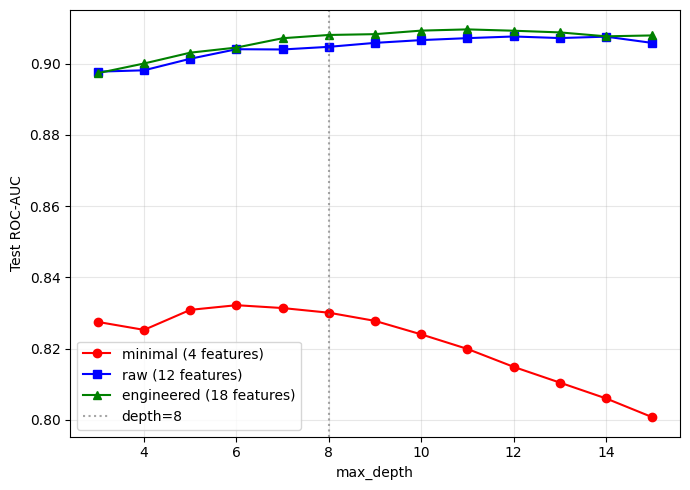

In [ ]:
def make_figure17_size_3200():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:3200]
    ytr_sub = ytr[:3200]
    Xtr_eng_sub = Xtr_eng[:3200]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_raw = Pipeline([('pre', pre_raw), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_raw.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p_raw.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_eng = Pipeline([('pre', pre_eng), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_eng.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure17_size_3200()
print(f"Depth sweep complete. Peak Engineered ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Depth sweep complete. Peak Engineered ROC-AUC of 0.9116 found at depth 13.


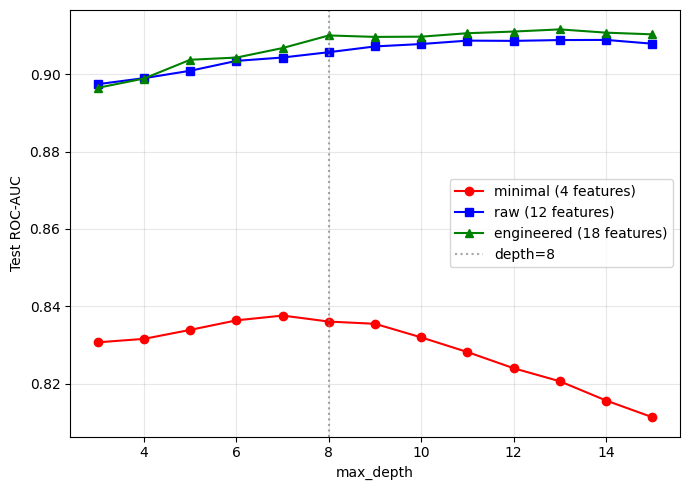

In [ ]:
def make_figure18_size_6400():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:6400]
    ytr_sub = ytr[:6400]
    Xtr_eng_sub = Xtr_eng[:6400]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_raw = Pipeline([('pre', pre_raw), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_raw.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p_raw.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_eng = Pipeline([('pre', pre_eng), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_eng.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure18_size_6400()
print(f"Depth sweep complete. Peak Engineered ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Depth sweep complete. Peak Engineered ROC-AUC of 0.9145 found at depth 14.


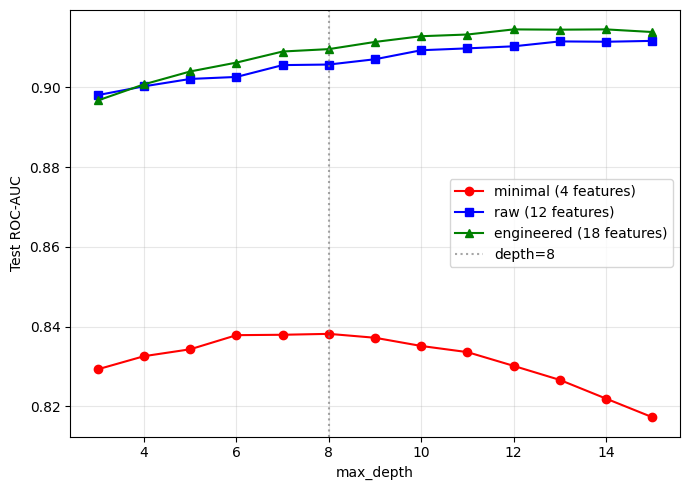

In [ ]:
def make_figure19_size_12800():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr[:12800]
    ytr_sub = ytr[:12800]
    Xtr_eng_sub = Xtr_eng[:12800]

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_raw = Pipeline([('pre', pre_raw), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_raw.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p_raw.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_eng = Pipeline([('pre', pre_eng), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_eng.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure19_size_12800()
print(f"Depth sweep complete. Peak Engineered ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Depth sweep complete. Peak Engineered ROC-AUC of 0.9180 found at depth 14.


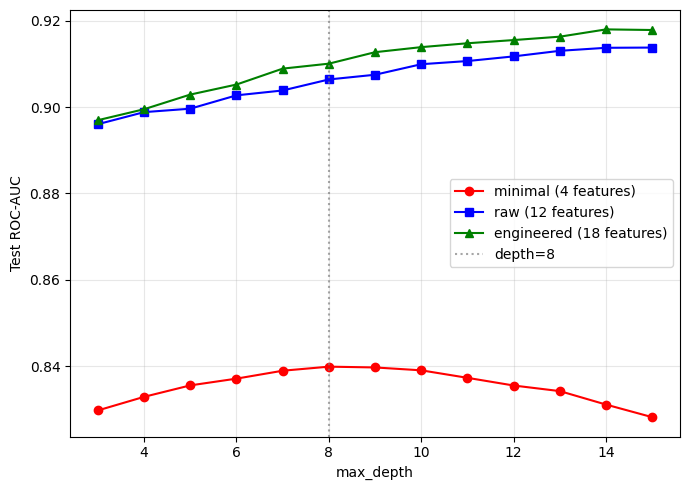

In [ ]:
def make_figure20_size_whole():
    Xtr_eng = add_features(Xtr)
    Xtr_sub = Xtr
    ytr_sub = ytr
    Xtr_eng_sub = Xtr_eng

    depths = list(range(3, 16))
    min_scores, raw_scores, eng_scores = [], [], []

    for depth in depths:
        # 1. Minimal features
        pre_4 = ColumnTransformer([
            ('num', StandardScaler(), num_4),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_4)
        ])
        p_min = Pipeline([('pre', pre_4), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_min.fit(Xtr_sub[num_4 + cat_4], ytr_sub)
        min_scores.append(roc_auc_score(yte, p_min.predict_proba(Xte[num_4 + cat_4])[:, 1]))

        # 2. Raw features
        pre_raw = ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_raw = Pipeline([('pre', pre_raw), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_raw.fit(Xtr_sub, ytr_sub)
        raw_scores.append(roc_auc_score(yte, p_raw.predict_proba(Xte)[:, 1]))

        # 3. Engineered features
        pre_eng = ColumnTransformer([
            ('num', StandardScaler(), num_eng),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])
        p_eng = Pipeline([('pre', pre_eng), ('clf', RandomForestClassifier(max_depth=depth, random_state=42))])
        p_eng.fit(Xtr_eng_sub, ytr_sub)
        eng_scores.append(roc_auc_score(yte, p_eng.predict_proba(Xte_eng)[:, 1]))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(depths, min_scores, 'o-', label='minimal (4 features)', color='red')
    ax.plot(depths, raw_scores, 's-', label='raw (12 features)', color='blue')
    ax.plot(depths, eng_scores, '^-', label='engineered (18 features)', color='green')
    ax.axvline(8, color='gray', linestyle=':', alpha=0.7, label='depth=8')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Test ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return depths, min_scores, raw_scores, eng_scores

de, min_sco, raw_sco, eng_sco = make_figure20_size_whole()
print(f"Depth sweep complete. Peak Engineered ROC-AUC of {max(eng_sco):.4f} found at depth {de[np.argmax(eng_sco)]}.")

In [ ]:
import warnings
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
from sklearn.pipeline import Pipeline

# Split the initial data
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define depths and sample sizes
depths = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
sample_sizes = [200, 400, 800, 1600, 3200, 6400, 12800, len(X_train_full)]

def generate_size_vs_depth_dataframe(model_class, model_name):
    # Initialize a matrix to store scores
    grid_data = np.zeros((len(depths), len(sample_sizes)))

    # Suppress unknown category UserWarnings during the sweep to keep output clean
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)

        for i, depth in enumerate(depths):
            for j, size in enumerate(sample_sizes):
                # Sub-sample the training data
                X_train_sub, y_train_sub = resample(
                    X_train_full, y_train_full,
                    n_samples=size,
                    random_state=42,
                    stratify=y_train_full
                )

                # Train the pipeline
                model = model_class(max_depth=depth, random_state=42)
                pipe = Pipeline([
                    ('pre', pre_raw),
                    ('clf', model)
                ])
                pipe.fit(X_train_sub, y_train_sub)
                probs = pipe.predict_proba(X_test)[:, 1]
                auc = roc_auc_score(y_test, probs)

                grid_data[i, j] = auc

    # Format as a clean Pandas DataFrame
    columns = [str(s) if s != len(X_train_full) else "Whole (39k)" for s in sample_sizes]
    df_grid = pd.DataFrame(grid_data, index=depths, columns=columns)
    df_grid.index.name = 'Max Depth'
    df_grid.columns.name = 'Sample Size'
    return df_grid

# Generate and display Decision Tree grid
dt_grid = generate_size_vs_depth_dataframe(DecisionTreeClassifier, "Decision Tree")
print("\n=== Decision Tree: ROC-AUC Grid (Size vs. Depth) ===")
display(dt_grid.round(4))

# Generate and display Random Forest grid
rf_grid = generate_size_vs_depth_dataframe(RandomForestClassifier, "Random Forest")
print("\n=== Random Forest: ROC-AUC Grid (Size vs. Depth) ===")
display(rf_grid.round(4))


=== Decision Tree: ROC-AUC Grid (Size vs. Depth) ===


Sample Size,200,400,800,1600,3200,6400,12800,Whole (39k)
Max Depth,,,,,,,,
3,0.8238,0.8420,0.8519,0.8435,0.8473,0.8540,0.8601,0.8539
4,0.8310,0.8537,0.8575,0.8431,0.8635,0.8717,0.8726,0.8654
5,0.8041,0.8401,0.8655,0.8484,0.8744,0.8780,0.8822,0.8782
6,0.7868,0.8385,0.8598,0.8629,0.8800,0.8855,0.8875,0.8893
7,0.7793,0.8384,0.8385,0.8596,0.8786,0.8824,0.8936,0.8954
8,0.8018,0.8198,0.8120,0.8535,0.8732,0.8834,0.8908,0.8965
9,0.7517,0.7983,0.7948,0.8125,0.8709,0.8719,0.8852,0.8964
10,0.7512,0.7897,0.7848,0.8177,0.8603,0.8654,0.8800,0.8936
11,0.7563,0.8005,0.7769,0.8023,0.8494,0.8536,0.8730,0.8912



=== Random Forest: ROC-AUC Grid (Size vs. Depth) ===


Sample Size,200,400,800,1600,3200,6400,12800,Whole (39k)
Max Depth,,,,,,,,
3,0.8855,0.8905,0.8947,0.8983,0.8978,0.8971,0.8959,0.8962
4,0.8878,0.8885,0.8979,0.8976,0.8980,0.8983,0.8975,0.8990
5,0.8893,0.8901,0.8980,0.8988,0.9000,0.9013,0.9018,0.9002
6,0.8925,0.8881,0.8979,0.9008,0.9019,0.9030,0.9034,0.9021
7,0.8890,0.8867,0.8991,0.9001,0.9028,0.9049,0.9053,0.9040
8,0.8883,0.8872,0.8981,0.9024,0.9035,0.9055,0.9058,0.9055
9,0.8858,0.8876,0.8987,0.9011,0.9040,0.9060,0.9088,0.9070
10,0.8843,0.8859,0.8982,0.9004,0.9047,0.9071,0.9094,0.9088
11,0.8844,0.8838,0.8968,0.9011,0.9049,0.9073,0.9114,0.9097


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 1. Define feature sets
minimal_features = ['age', 'education_num', 'occupation', 'sex']
full_features = [col for col in df.columns if col != 'income']

# 2. Define the sample size points for your graph
sample_sizes = [200, 400, 800, 1600, 3200, 6400]

table_data = []

for n in sample_sizes:
    # Isolate the specific sample size
    df_sample = df.sample(n=n, random_state=42)

    # Separate features and target
    X_min = pd.get_dummies(df_sample[minimal_features])
    X_full = pd.get_dummies(df_sample[full_features])
    y = df_sample['income']

    # Apply 80/20 Train/Test Split
    # Using the same random state ensures the splits align perfectly
    X_min_train, X_min_test, y_train, y_test = train_test_split(
        X_min, y, test_size=0.20, random_state=42
    )
    X_full_train, X_full_test, _, _ = train_test_split(
        X_full, y, test_size=0.20, random_state=42
    )

    # 3. Decision Tree Evaluation
    # Note: max_depth is set to 5 here to control variance at low N, adjust as needed
    dt_min = DecisionTreeClassifier(max_depth=5, random_state=42)
    dt_min.fit(X_min_train, y_train)
    dt_roc_min = roc_auc_score(y_test, dt_min.predict_proba(X_min_test)[:, 1])

    dt_full = DecisionTreeClassifier(max_depth=5, random_state=42)
    dt_full.fit(X_full_train, y_train)
    dt_roc_full = roc_auc_score(y_test, dt_full.predict_proba(X_full_test)[:, 1])

    # 4. Random Forest Evaluation
    rf_min = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    rf_min.fit(X_min_train, y_train)
    rf_roc_min = roc_auc_score(y_test, rf_min.predict_proba(X_min_test)[:, 1])

    rf_full = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    rf_full.fit(X_full_train, y_train)
    rf_roc_full = roc_auc_score(y_test, rf_full.predict_proba(X_full_test)[:, 1])

    # 5. Store the data points for the table
    table_data.append({
        'Sample Size': n,
        'DT Minimal': round(dt_roc_min, 4),
        'DT Full': round(dt_roc_full, 4),
        'RF Minimal': round(rf_roc_min, 4),
        'RF Full': round(rf_roc_full, 4)
    })

# Print the final grid so you can plot your points
results_df = pd.DataFrame(table_data)
print(results_df.to_string(index=False))

 Sample Size  DT Minimal  DT Full  RF Minimal  RF Full
         200      0.7931   0.7382      0.7806   0.8339
         400      0.5649   0.6844      0.6937   0.7694
         800      0.7410   0.7820      0.8206   0.8459
        1600      0.7714   0.8341      0.8027   0.8532
        3200      0.8108   0.8284      0.8289   0.8797
        6400      0.8081   0.8708      0.8267   0.8946
